# Final Project – Data Visualization
## Câu hỏi nghiên cứu:

- **Các quốc gia và lục địa nào dẫn đầu về tăng trưởng dân số toàn cầu.**
- **Và liệu tốc độ tăng trưởng dân số có tương quan với mật độ dân số và diện tích lãnh thổ của các quốc gia hay không?**



### Dataset
- **Nguồn:** World Population Dataset
- **Nội dung:** Dân số 234 quốc gia/vùng lãnh thổ qua các năm: 1970, 1980, 1990, 2000, 2010, 2015, 2020, 2022
- **Các biến chính:** `Population`, `Area`, `Density`, `Growth Rate`, `Continent`, `World Population Percentage`

## Cài thư viện:


In [36]:
# Nếu chưa cài, chạy lệnh này:
# !pip install pandas matplotlib seaborn plotly wordcloud geopandas


In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
import seaborn as sns
import plotly.express as px
from wordcloud import WordCloud
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Cài đặt style chung
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 120
print("Thư viện đã sẵn sàng!")

Thư viện đã sẵn sàng!


In [38]:
# Palette màu thống nhất lục địa cho toàn notebook:
PALETTE_CONTINENT = {
    'Asia':          '#2196F3',
    'Africa':        '#FF9800',
    'Europe':        '#9C27B0',
    'North America': '#4CAF50',
    'South America': '#F44336',
    'Oceania':       '#00BCD4'
}

## Đọc dữ liệu:

In [39]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [40]:
# === TẢI VÀ KHÁM PHÁ DỮ LIỆU ===
df = pd.read_csv('/content/drive/MyDrive/NĂM 3_2302220_ĐẠI HỌC TÂN TẠO/SPRING 2026_Năm 3_ĐH Tân Tạo/CS441V_Data Visualization_Thầy Hà/Final Project/world_population.csv')

# Đổi tên cột cho gọn
df = df.rename(columns={
    'Country/Territory': 'Country',
    'Area (km²)': 'Area_km2',
    'Density (per km²)': 'Density',
    'Growth Rate': 'GrowthRate',
    'World Population Percentage': 'WorldPct',
    '2022 Population': 'Pop2022',
    '2020 Population': 'Pop2020',
    '2015 Population': 'Pop2015',
    '2010 Population': 'Pop2010',
    '2000 Population': 'Pop2000',
    '1990 Population': 'Pop1990',
    '1980 Population': 'Pop1980',
    '1970 Population': 'Pop1970'
})

print(f"Dataset: {df.shape[0]} quốc gia, {df.shape[1]} cột")
print(f"Số lục địa: {df['Continent'].nunique()} ({', '.join(df['Continent'].unique())})")
print(f"Dân số thế giới 2022: {df['Pop2022'].sum():,.0f} người")


Dataset: 234 quốc gia, 17 cột
Số lục địa: 6 (Asia, Europe, Africa, Oceania, North America, South America)
Dân số thế giới 2022: 7,973,413,042 người


In [41]:
df.head()


,Rank,CCA3,Country,Capital,Continent,Pop2022,Pop2020,Pop2015,Pop2010,Pop2000,Pop1990,Pop1980,Pop1970,Area_km2,Density,GrowthRate,WorldPct
0,36,AFG,Afghanistan,Kabul,Asia,41128771,38972230,33753499,28189672,19542982,10694796,12486631,10752971,652230,63.0587,1.0257,0.52
1,138,ALB,Albania,Tirana,Europe,2842321,2866849,2882481,2913399,3182021,3295066,2941651,2324731,28748,98.8702,0.9957,0.04
2,34,DZA,Algeria,Algiers,Africa,44903225,43451666,39543154,35856344,30774621,25518074,18739378,13795915,2381741,18.8531,1.0164,0.56
3,213,ASM,American Samoa,Pago Pago,Oceania,44273,46189,51368,54849,58230,47818,32886,27075,199,222.4774,0.9831,0.00
4,203,AND,Andorra,Andorra la Vella,Europe,79824,77700,71746,71519,66097,53569,35611,19860,468,170.5641,1.0100,0.00


In [42]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 234 entries, 0 to 233
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Rank        234 non-null    int64  
 1   CCA3        234 non-null    object 
 2   Country     234 non-null    object 
 3   Capital     234 non-null    object 
 4   Continent   234 non-null    object 
 5   Pop2022     234 non-null    int64  
 6   Pop2020     234 non-null    int64  
 7   Pop2015     234 non-null    int64  
 8   Pop2010     234 non-null    int64  
 9   Pop2000     234 non-null    int64  
 10  Pop1990     234 non-null    int64  
 11  Pop1980     234 non-null    int64  
 12  Pop1970     234 non-null    int64  
 13  Area_km2    234 non-null    int64  
 14  Density     234 non-null    float64
 15  GrowthRate  234 non-null    float64
 16  WorldPct    234 non-null    float64
dtypes: float64(3), int64(10), object(4)
memory usage: 31.2+ KB


In [43]:
# size of dataframe (rows, columns)
df.shape

(234, 17)

In [44]:
df.describe().T.style.background_gradient(cmap="Blues").format("{:.2f}")


,count,mean,std,min,25%,50%,75%,max
Rank,234.00,117.50,67.69,1.00,59.25,117.50,175.75,234.00
Pop2022,234.00,34074414.71,136766424.80,510.00,419738.50,5559944.50,22476504.75,1425887337.00
Pop2020,234.00,33501070.95,135589876.92,520.00,415284.50,5493074.50,21447979.50,1424929781.00
Pop2015,234.00,31729956.24,130404992.75,564.00,404676.00,5307400.00,19730853.75,1393715448.00
Pop2010,234.00,29845235.03,124218487.63,596.00,393149.00,4942770.50,19159567.50,1348191368.00
Pop2000,234.00,26269468.82,111698206.72,651.00,327242.00,4292907.00,15762301.00,1264099069.00
Pop1990,234.00,22710220.79,97832173.35,700.00,264115.75,3825409.50,11869231.00,1153704252.00
Pop1980,234.00,18984616.97,81785186.08,733.00,229614.25,3141145.50,9826053.75,982372466.00
Pop1970,234.00,15786908.81,67795091.64,752.00,155997.00,2604830.00,8817329.00,822534450.00
Area_km2,234.00,581449.38,1761840.86,1.00,2650.00,81199.50,430425.75,17098242.00


**Nhận xét ban đầu:**
- Dataset gồm **234 quốc gia/vùng lãnh thổ**, không có giá trị thiếu.
- Dân số năm 2022 trải dài từ vài trăm người (Vatican) đến hơn 1,4 tỷ người (Trung Quốc, Ấn Độ).
- Tốc độ tăng trưởng (`Growth Rate`) dao động từ khoảng 0.91 (suy giảm) đến 1.07 (tăng mạnh).


## Xử lý dữ liệu:

In [45]:
# Kiểm tra giá trị thiếu
print("Giá trị thiếu:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Chuyển về dạng % tăng trưởng
df['GrowthRate_pct'] = (df['GrowthRate'] - 1) * 100


Giá trị thiếu:
Series([], dtype: int64)


In [46]:
# Tạo DataFrame dạng long (melted) để vẽ trend theo thời gian
year_cols = ['Pop1970', 'Pop1980', 'Pop1990', 'Pop2000', 'Pop2010', 'Pop2015', 'Pop2020', 'Pop2022']
year_map  = {'Pop1970':1970,'Pop1980':1980,'Pop1990':1990,'Pop2000':2000,
             'Pop2010':2010,'Pop2015':2015,'Pop2020':2020,'Pop2022':2022}

df_long = df.melt(
    id_vars=['Country', 'CCA3', 'Continent', 'Area_km2', 'Density', 'GrowthRate_pct'],
    value_vars=year_cols,
    var_name='Year_col',
    value_name='Population'
)
df_long['Year'] = df_long['Year_col'].map(year_map)

print("\nDữ liệu đã sẵn sàng!")
df_long.head()



Dữ liệu đã sẵn sàng!


,Country,CCA3,Continent,Area_km2,Density,GrowthRate_pct,Year_col,Population,Year
0,Afghanistan,AFG,Asia,652230,63.0587,2.57,Pop1970,10752971,1970
1,Albania,ALB,Europe,28748,98.8702,-0.43,Pop1970,2324731,1970
2,Algeria,DZA,Africa,2381741,18.8531,1.64,Pop1970,13795915,1970
3,American Samoa,ASM,Oceania,199,222.4774,-1.69,Pop1970,27075,1970
4,Andorra,AND,Europe,468,170.5641,1.00,Pop1970,19860,1970


## Câu 1: Phân phối tổng thể (Histogram)

**Bối cảnh:** Trước khi so sánh các quốc gia, cần hiểu dân số 234 quốc gia trên thế giới phân bổ như thế nào - đa số nước có dân số nhỏ hay lớn?

- **Yêu cầu:** Vẽ **Histogram** cho cột `Pop2022` (dân số năm 2022).
- **Hướng đi:** Phần lớn dữ liệu sẽ bị lệch phải (right-skewed) do một vài siêu cường về dân số. Thử dùng `np.log10()` để transform trục X và so sánh hai biểu đồ với nhau.

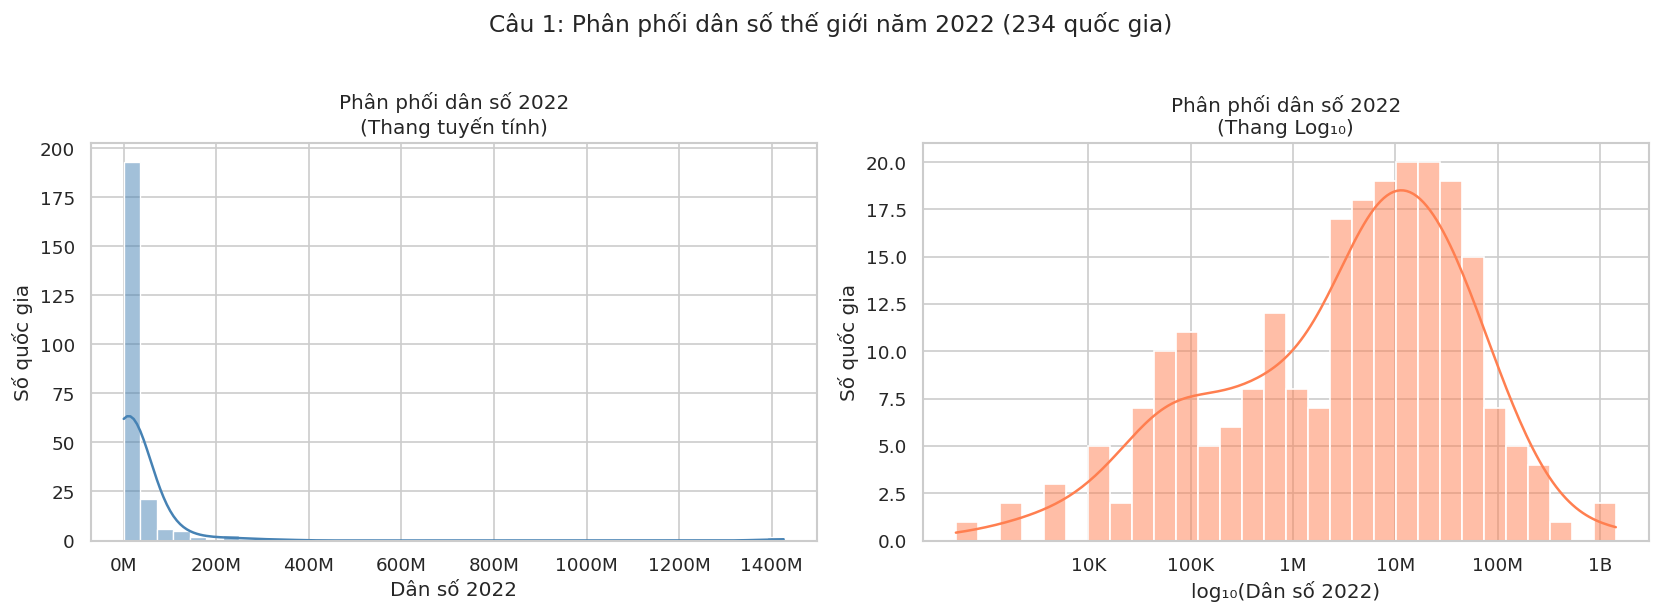


Insight: 74 / 234 quốc gia có dân số dưới 1 triệu người.
   Chỉ 14 quốc gia vượt mốc 100 triệu dân.


In [47]:
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Biểu đồ trái: thang tuyến tính
sns.histplot(data=df, x='Pop2022', bins=40, kde=True, color='steelblue', ax=axes[0])
axes[0].set_title('Phân phối dân số 2022\n(Thang tuyến tính)', fontsize=12)
axes[0].set_xlabel('Dân số 2022')
axes[0].set_ylabel('Số quốc gia')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))

# Biểu đồ phải: thang log
df['Log_Pop2022'] = np.log10(df['Pop2022'])
sns.histplot(data=df, x='Log_Pop2022', bins=30, kde=True, color='coral', ax=axes[1])
axes[1].set_title('Phân phối dân số 2022\n(Thang Log₁₀)', fontsize=12)
axes[1].set_xlabel('log₁₀(Dân số 2022)')
axes[1].set_ylabel('Số quốc gia')
axes[1].set_xticks([4, 5, 6, 7, 8, 9])
axes[1].set_xticklabels(['10K', '100K', '1M', '10M', '100M', '1B'])

fig.suptitle('Câu 1: Phân phối dân số thế giới năm 2022 (234 quốc gia)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f"\nInsight: {(df['Pop2022'] < 1e6).sum()} / {len(df)} quốc gia có dân số dưới 1 triệu người.")
print(f"   Chỉ {(df['Pop2022'] > 1e8).sum()} quốc gia vượt mốc 100 triệu dân.")

### **Insight Câu 1:**
- **74 / 234 quốc gia (31.6%)** có dân số dưới 1 triệu người – đa số các quốc gia trên thế giới là nhỏ.
- Chỉ **14 quốc gia** vượt mốc 100 triệu dân nhưng cộng lại chiếm phần lớn dân số toàn cầu.
- Thang log₁₀ cho thấy phân phối **gần đối xứng (log-normal)**, đỉnh ở 10⁶–10⁷ người → đây là khoảng dân số phổ biến nhất.

## Câu 2: Chiếm tỷ trọng như thế nào? (Pie Chart + Bar Chart)

**Bối cảnh:** Histogram ở Câu 1 cho thấy phân phối rất lệch. Vậy từng **lục địa** chiếm bao nhiêu % dân số thế giới? Và trong đó, **10 quốc gia đông dân nhất** chiếm bao nhiêu?

- **Yêu cầu:** Vẽ **Pie Chart** tỷ trọng dân số theo lục địa, và **Horizontal Bar Chart** top 10 quốc gia.
- **Hướng đi:** Gộp theo lục địa dùng `.groupby('Continent')['Pop2022'].sum()`. Dùng `autopct='%1.1f%%'` cho Pie Chart.

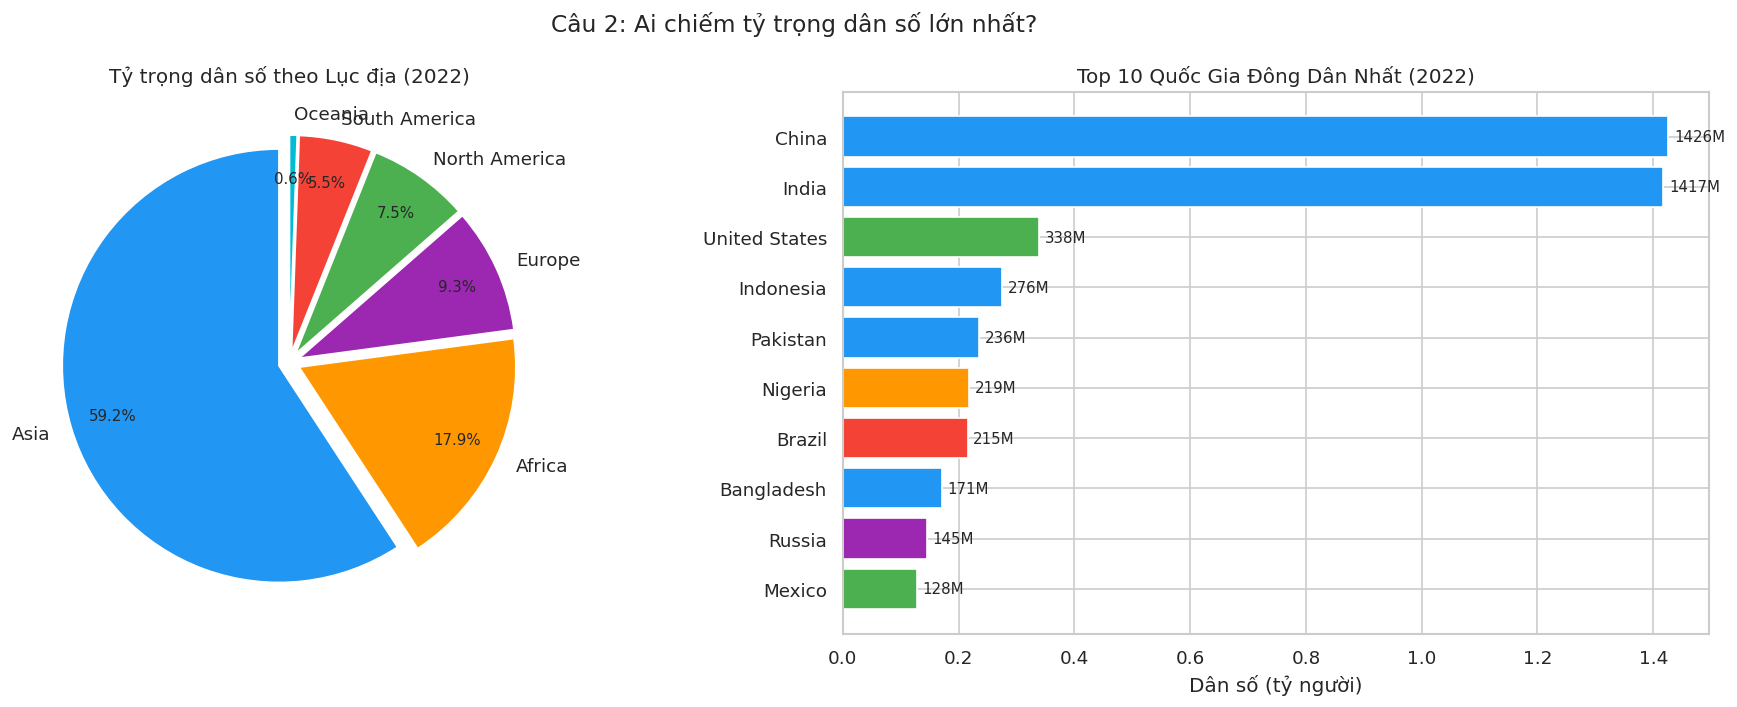


Insight câu 2: Châu Á chiếm 59.2% dân số thế giới.
   Chỉ 10 quốc gia đã chiếm 57.3% tổng dân số toàn cầu!


In [48]:
#Dữ liệu
continent_pop = df.groupby('Continent')['Pop2022'].sum().sort_values(ascending=False)
top10 = df.nlargest(10, 'Pop2022')[['Country', 'Pop2022', 'Continent']]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

#Pie Chart
pie_colors = [PALETTE_CONTINENT[c] for c in continent_pop.index]
wedges, texts, autotexts = axes[0].pie(
    continent_pop.values,
    labels=continent_pop.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=pie_colors,
    pctdistance=0.80,
    explode=[0.05]*len(continent_pop)
)
for at in autotexts:
    at.set_fontsize(9)
axes[0].set_title('Tỷ trọng dân số theo Lục địa (2022)', fontsize=12)



#Horizontal Bar Chart
bar_colors = [PALETTE_CONTINENT.get(c, 'gray') for c in top10['Continent']]

bars = axes[1].barh(top10['Country'], top10['Pop2022']/1e9, color=bar_colors)
axes[1].set_xlabel('Dân số (tỷ người)')
axes[1].set_title('Top 10 Quốc Gia Đông Dân Nhất (2022)', fontsize=12)
axes[1].invert_yaxis()
for bar, (_, row) in zip(bars, top10.iterrows()):
    axes[1].text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                 f"{row['Pop2022']/1e6:.0f}M", va='center', fontsize=9)

fig.suptitle('Câu 2: Ai chiếm tỷ trọng dân số lớn nhất?', fontsize=14)
plt.tight_layout()
plt.show()

top10_pct = top10['Pop2022'].sum() / df['Pop2022'].sum() * 100
print(f"\nInsight câu 2: Châu Á chiếm {continent_pop['Asia']/df['Pop2022'].sum()*100:.1f}% dân số thế giới.")
print(f"   Chỉ 10 quốc gia đã chiếm {top10_pct:.1f}% tổng dân số toàn cầu!")

### Insight Câu 2:
- **Châu Á chiếm ~59.2%** dân số thế giới áp đảo so với các lục địa còn lại.
- **Châu Phi đứng thứ hai (~17.9%)** và đang trên đà tăng mạnh nhất (sẽ phân tích kỹ ở Câu 3–4).
- Chỉ **10 quốc gia** đã chiếm **~57.3%** tổng dân số toàn cầu – mức độ tập trung cực kỳ bất đối xứng.
- **Ấn Độ (1,417M)** và **Trung Quốc (1,412M)** dẫn đầu tuyệt đối, cộng lại chiếm ~36% dân số thế giới.



## Câu 3: Dân Số Biến Động Như Thế Nào Theo Thời Gian? (Line Chart)

**Bối cảnh:** Câu 2 cho thấy tỷ trọng hiện tại. Nhưng **xu hướng tăng trưởng** theo thời gian (1970–2022) của từng lục địa diễn ra như thế nào? Lục địa nào đang tăng tốc, lục địa nào đang chững lại?

- **Yêu cầu:** Vẽ **Line Chart** dân số theo năm, phân theo từng lục địa.
- **Hướng đi:** Dùng `df_long` đã tạo sẵn. Group theo `['Continent', 'Year']` rồi `.sum()`. Dùng `hue='Continent'` trong `sns.lineplot()`.

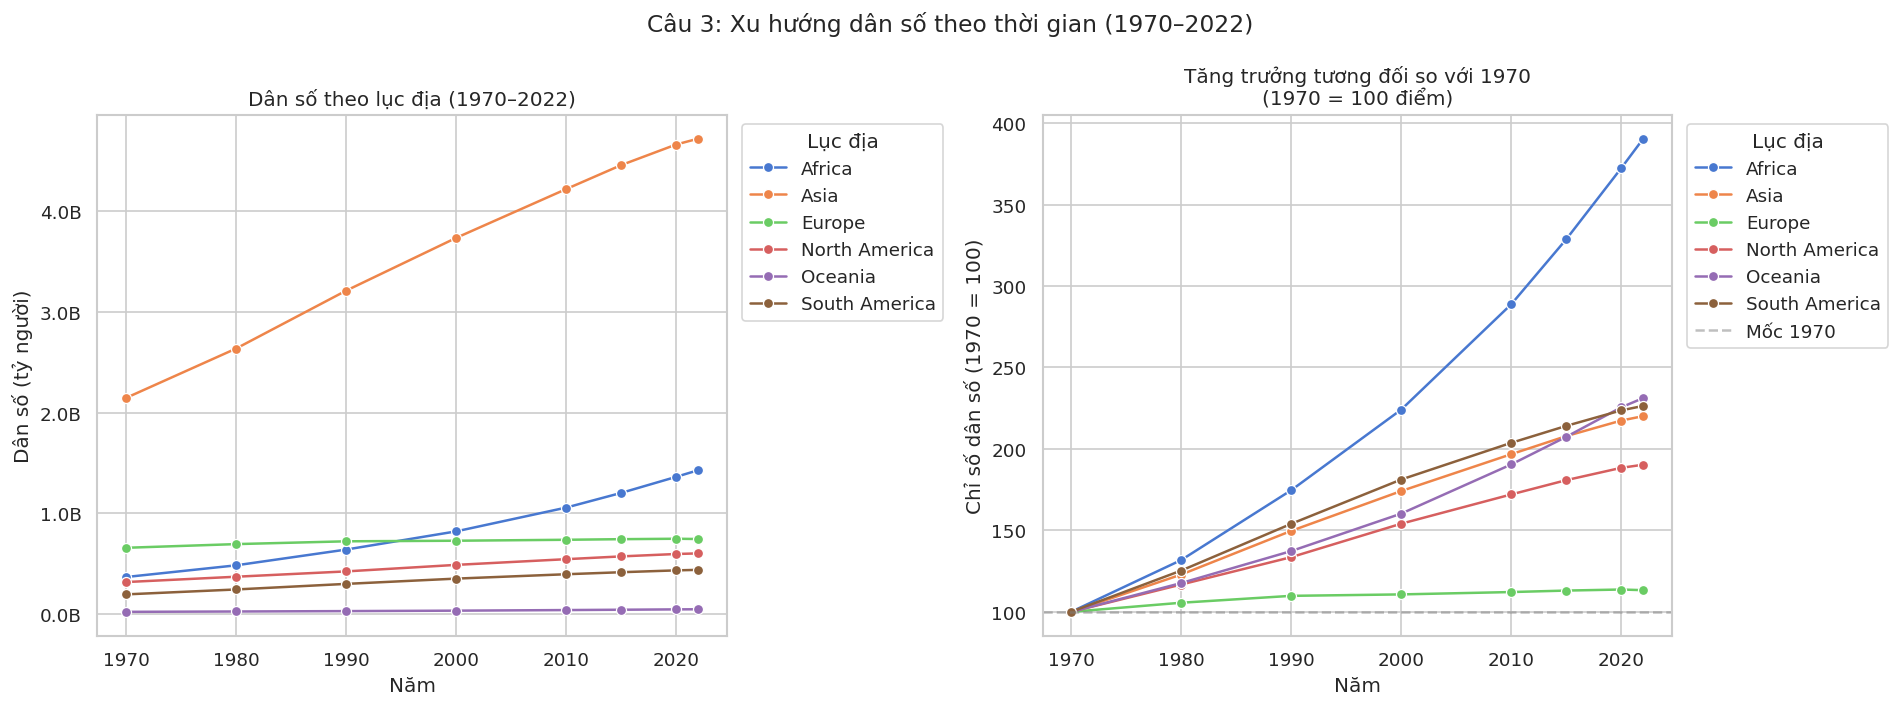


Insight: Châu Phi tăng trưởng mạnh nhất, dân số năm 2022 gấp 3.9x so với năm 1970!
   Trong khi đó, Châu Âu gần như tăng trưởng bằng 0 sau năm 2000.


In [49]:
#Tổng hợp dân số theo lục địa + năm
continent_time = df_long.groupby(['Continent', 'Year'])['Population'].sum().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

#Biểu đồ trái: Tuyệt đối
sns.lineplot(data=continent_time, x='Year', y='Population',
             hue='Continent', marker='o', ax=axes[0])

axes[0].set_title('Dân số theo lục địa (1970–2022)', fontsize=12)
axes[0].set_xlabel('Năm')
axes[0].set_ylabel('Dân số (tỷ người)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e9:.1f}B'))
axes[0].legend(title='Lục địa', bbox_to_anchor=(1.01, 1), loc='upper left')

#Biểu đồ phải: Chuẩn hóa (base 1970 = 100)
base = continent_time[continent_time['Year']==1970].set_index('Continent')['Population']
continent_time['Pop_indexed'] = continent_time.apply(
    lambda r: r['Population'] / base[r['Continent']] * 100, axis=1
)
sns.lineplot(data=continent_time, x='Year', y='Pop_indexed',
             hue='Continent', marker='o', ax=axes[1])
axes[1].axhline(y=100, color='gray', linestyle='--', alpha=0.5, label='Mốc 1970')
axes[1].set_title('Tăng trưởng tương đối so với 1970\n(1970 = 100 điểm)', fontsize=12)
axes[1].set_xlabel('Năm')
axes[1].set_ylabel('Chỉ số dân số (1970 = 100)')
axes[1].legend(title='Lục địa', bbox_to_anchor=(1.01, 1), loc='upper left')

fig.suptitle('Câu 3: Xu hướng dân số theo thời gian (1970–2022)', fontsize=14)
plt.tight_layout()
plt.show()

africa_growth = continent_time[(continent_time['Continent']=='Africa')]
g = africa_growth[africa_growth['Year']==2022]['Pop_indexed'].values[0]

print(f"\nInsight: Châu Phi tăng trưởng mạnh nhất, dân số năm 2022 gấp {g/100:.1f}x so với năm 1970!")
print(f"   Trong khi đó, Châu Âu gần như tăng trưởng bằng 0 sau năm 2000.")

In [50]:
# Tính mức tăng tuyệt đối mỗi lục địa từ 1970 đến 2022
df_cont_pivot = continent_time[continent_time['Year'].isin([1970, 2022])].pivot_table(
    index='Continent', columns='Year', values='Population'
).reset_index()
df_cont_pivot.columns.name = None
df_cont_pivot = df_cont_pivot.rename(columns={1970: '1970 Population', 2022: '2022 Population'})

df_cont_pivot['Increase_50yr'] = df_cont_pivot['2022 Population'] - df_cont_pivot['1970 Population']
df_cont_pivot['Increase_pct']  = (df_cont_pivot['Increase_50yr'] / df_cont_pivot['1970 Population']) * 100

result = df_cont_pivot[['Continent','1970 Population','2022 Population','Increase_50yr','Increase_pct']].sort_values('Increase_pct', ascending=False)
display(result.style.format({
    '1970 Population':'{:,.0f}',
    '2022 Population':'{:,.0f}',
    'Increase_50yr':'{:,.0f}',
    'Increase_pct':'{:.1f}%'
}).background_gradient(subset='Increase_pct', cmap='Oranges'))

,Continent,1970 Population,2022 Population,Increase_50yr,Increase_pct
0,Africa,"365,444,348","1,426,730,932","1,061,286,584",290.4%
4,Oceania,"19,480,270","45,038,554","25,558,284",131.2%
5,South America,"192,947,156","436,816,608","243,869,452",126.4%
1,Asia,"2,144,906,290","4,721,383,274","2,576,476,984",120.1%
3,North America,"315,434,606","600,296,136","284,861,530",90.3%
2,Europe,"655,923,991","743,147,538","87,223,547",13.3%


### **Insight Câu 3:**
- **Châu Phi** tăng trưởng mạnh nhất trong 50 năm: tăng hơn **300%**, từ ~360 triệu lên ~1.4 tỷ người.
- **Châu Á** tăng về số lượng tuyệt đối nhiều nhất (~2.4 tỷ người) nhưng đường tăng đang dần phẳng lại từ sau 2015.
- **Châu Âu** gần như không thay đổi và đang có xu hướng giảm nhẹ - phản ánh hiện tượng già hóa dân số.



## Câu 4: Ai Đang Tăng Trưởng Nhanh Nhất? (Box Plot)

**Bối cảnh:** Line Chart ở Câu 3 cho thấy Châu Phi đang tăng mạnh. Nhưng **tốc độ tăng trưởng** (`Growth Rate`) giữa các lục địa phân bổ như thế nào? Lục địa nào có nhiều quốc gia tăng trưởng âm (dân số giảm)?

- **Yêu cầu:** Vẽ **Box Plot** so sánh `GrowthRate_pct` giữa 6 lục địa.
- **Hướng đi:** Dùng `sns.boxplot(x='Continent', y='GrowthRate_pct')`. Thêm `sns.stripplot()` phía trên để thấy từng điểm dữ liệu. Kẻ một đường `axhline(y=0)` để phân biệt tăng trưởng dương/âm.

In [51]:
neg_growth = df[df['GrowthRate_pct'] < 0]
pos_growth = df[df['GrowthRate_pct'] > 0]

# Bảng thống kê theo lục địa
continent_growth_stats = (df.groupby('Continent')['GrowthRate_pct']
                          .agg(['mean','median','min','max'])
                          .sort_values('median', ascending=False))
display(continent_growth_stats.style
        .background_gradient(subset=['median'], cmap='RdYlGn')
        .format({'mean':'{:.2f}%','median':'{:.2f}%','min':'{:.2f}%','max':'{:.2f}%'})
        .set_caption('Bảng 2. Thống kê tốc độ tăng trưởng (%) theo lục địa'))


,mean,median,min,max
Continent,,,,
Africa,2.12%,2.31%,0.04%,3.78%
Asia,0.94%,0.81%,-1.84%,3.76%
Oceania,0.74%,0.79%,-1.69%,2.38%
South America,0.80%,0.63%,-0.10%,2.39%
North America,0.42%,0.41%,-0.63%,1.50%
Europe,0.23%,0.15%,-8.80%,6.91%


In [52]:
# Top 10 quốc gia có tốc độ tăng trưởng âm:
top10_neg_growth = neg_growth.nsmallest(10, 'GrowthRate_pct')[['Country', 'Continent', 'Pop2022', 'GrowthRate_pct']]
display(top10_neg_growth.style.background_gradient(subset=['GrowthRate_pct'], cmap='Reds_r').format({
    'Pop2022': '{:,.0f}',
    'GrowthRate_pct': '{:.2f}%'
}))

# Top 10 quốc gia có tốc độ tăng trưởng dương:
top10_pos_growth = df.nlargest(10, 'GrowthRate_pct')[['Country', 'Continent', 'Pop2022', 'GrowthRate_pct']]
display(top10_pos_growth.style.background_gradient(subset=['GrowthRate_pct'], cmap='Greens').format({
    'Pop2022': '{:,.0f}',
    'GrowthRate_pct': '{:.2f}%'
}))

,Country,Continent,Pop2022,GrowthRate_pct
218,Ukraine,Europe,"39,701,739",-8.80%
112,Lebanon,Asia,"5,489,739",-1.84%
3,American Samoa,Oceania,"44,273",-1.69%
30,Bulgaria,Europe,"6,781,953",-1.51%
117,Lithuania,Europe,"2,750,055",-1.31%
111,Latvia,Europe,"1,850,651",-1.24%
25,Bosnia and Herzegovina,Europe,"3,233,526",-1.14%
126,Marshall Islands,Oceania,"41,569",-1.14%
184,Serbia,Europe,"7,221,365",-1.03%
46,Croatia,Europe,"4,030,358",-0.73%


,Country,Continent,Pop2022,GrowthRate_pct
133,Moldova,Europe,"3,272,996",6.91%
164,Poland,Europe,"39,857,145",4.04%
148,Niger,Africa,"26,207,977",3.78%
202,Syria,Asia,"22,125,249",3.76%
189,Slovakia,Europe,"5,643,453",3.59%
55,DR Congo,Africa,"99,010,212",3.25%
130,Mayotte,Africa,"326,101",3.19%
39,Chad,Africa,"17,723,315",3.16%
5,Angola,Africa,"35,588,987",3.15%
124,Mali,Africa,"22,593,590",3.14%


In [53]:
# Bảng tốc độ tăng trưởng (%) theo từng lục địa:
continent_growth_stats = df.groupby('Continent')['GrowthRate_pct'].agg(['mean', 'median', 'min', 'max']).sort_values('median', ascending=False)

display(continent_growth_stats.style.background_gradient(subset=['median'], cmap='Blues').format({
    'mean': '{:.2f}%',
    'median': '{:.2f}%',
    'min': '{:.2f}%',
    'max': '{:.2f}%'
}))


,mean,median,min,max
Continent,,,,
Africa,2.12%,2.31%,0.04%,3.78%
Asia,0.94%,0.81%,-1.84%,3.76%
Oceania,0.74%,0.79%,-1.69%,2.38%
South America,0.80%,0.63%,-0.10%,2.39%
North America,0.42%,0.41%,-0.63%,1.50%
Europe,0.23%,0.15%,-8.80%,6.91%


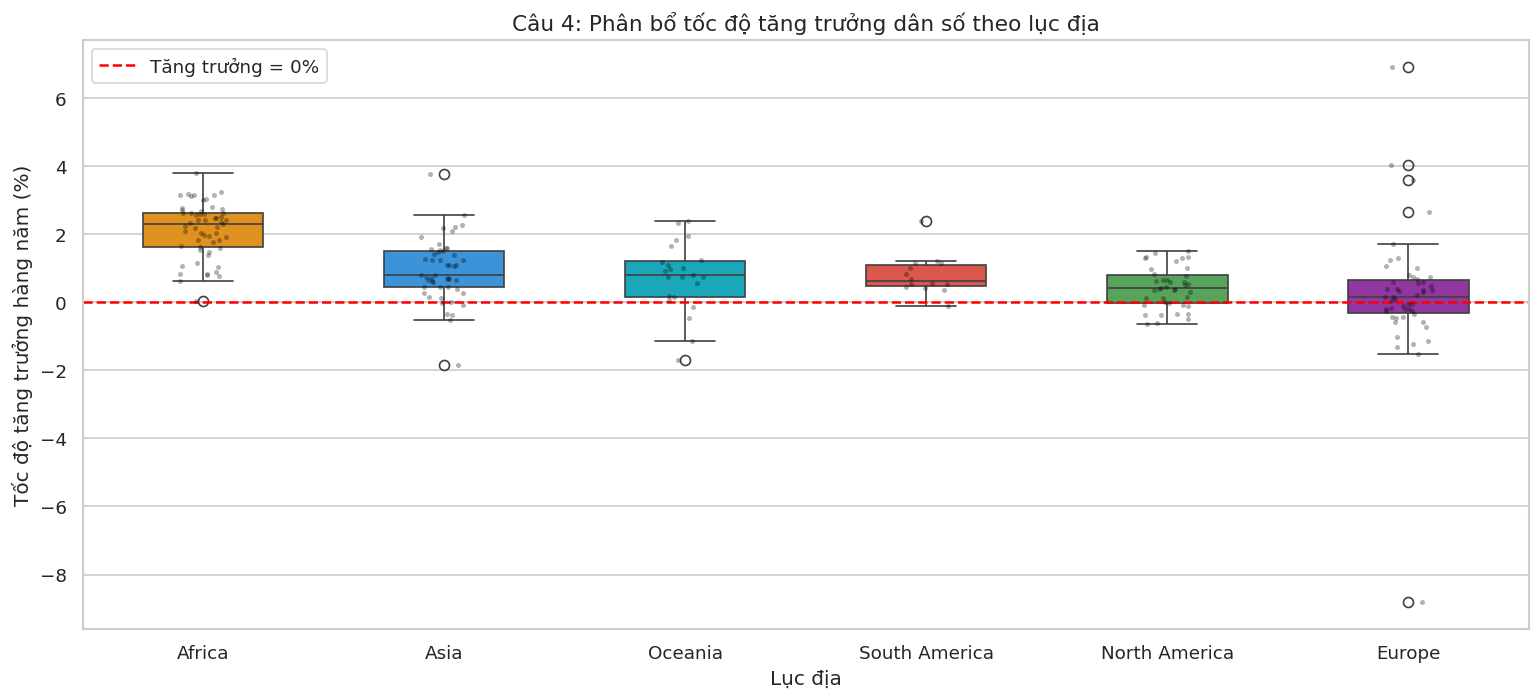


Insight Câu 4: 44 quốc gia có tốc độ tăng trưởng âm (dân số đang giảm).
   Trong đó có: Ukraine, Lebanon, American Samoa, Bulgaria, Lithuania...
   Châu Phi có trung vị tốc độ tăng trưởng cao nhất: 2.31%/năm


In [54]:
fig, ax = plt.subplots(figsize=(13, 6))

order = df.groupby('Continent')['GrowthRate_pct'].median().sort_values(ascending=False).index

sns.boxplot(data=df, x='Continent', y='GrowthRate_pct', order=order,
            palette=PALETTE_CONTINENT, width=0.5, ax=ax)
sns.stripplot(data=df, x='Continent', y='GrowthRate_pct', order=order,
              color='black', alpha=0.3, size=3, jitter=True, ax=ax)

ax.axhline(y=0, color='red', linestyle='--', linewidth=1.5, label='Tăng trưởng = 0%')
ax.set_title('Câu 4: Phân bổ tốc độ tăng trưởng dân số theo lục địa', fontsize=13)
ax.set_xlabel('Lục địa')
ax.set_ylabel('Tốc độ tăng trưởng hàng năm (%)')
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nInsight Câu 4: {len(neg_growth)} quốc gia có tốc độ tăng trưởng âm (dân số đang giảm).")

print(f"   Trong đó có: {', '.join(neg_growth.nsmallest(5, 'GrowthRate_pct')['Country'].tolist())}...")
print(f"   Châu Phi có trung vị tốc độ tăng trưởng cao nhất: {df[df['Continent']=='Africa']['GrowthRate_pct'].median():.2f}%/năm")

### Insight Câu 4:
- **Châu Phi** có trung vị tốc độ tăng trưởng **cao nhất (~2.5%/năm)**, với hầu hết các quốc gia tăng trưởng dương và ổn định.
- **44 quốc gia** trên thế giới có tốc độ tăng trưởng **âm** (dân số đang giảm), tập trung chủ yếu ở **Châu Âu**.
- **Outlier Ukraine (-8.8%/năm):** Đây là giá trị cực trị bất thường do tác động trực tiếp của xung đột Nga-Ukraine từ 2022, gây ra làn sóng tị nạn và di cư hàng loạt. Đây là xung đột địa chính trị.



## Câu 4b: Quốc Gia Nào Tăng Nhiều Nhất Về Số Lượng Tuyệt Đối? (Bar Chart)

**Bối cảnh:** Box Plot ở Câu 4 cho thấy *tốc độ* tăng trưởng (%). Nhưng để trả lời trực tiếp câu hỏi nghiên cứu *"quốc gia nào dẫn đầu về tăng trưởng dân số"*, ta cần xem thêm **mức tăng tuyệt đối** (số người tăng thêm) từ 1970–2022 – vì một nước tăng 3%/năm nhưng dân số nhỏ vẫn có thể ít người hơn một nước tăng 1.5%/năm nhưng đông dân.

- **Yêu cầu:** Vẽ **Horizontal Bar Chart** top 15 quốc gia tăng dân số nhiều nhất về giá trị tuyệt đối (1970 → 2022).
- **Hướng đi:** Tính cột `Pop_increase = Pop2022 - Pop1970`, lấy `nlargest(15)`, vẽ `barh`.


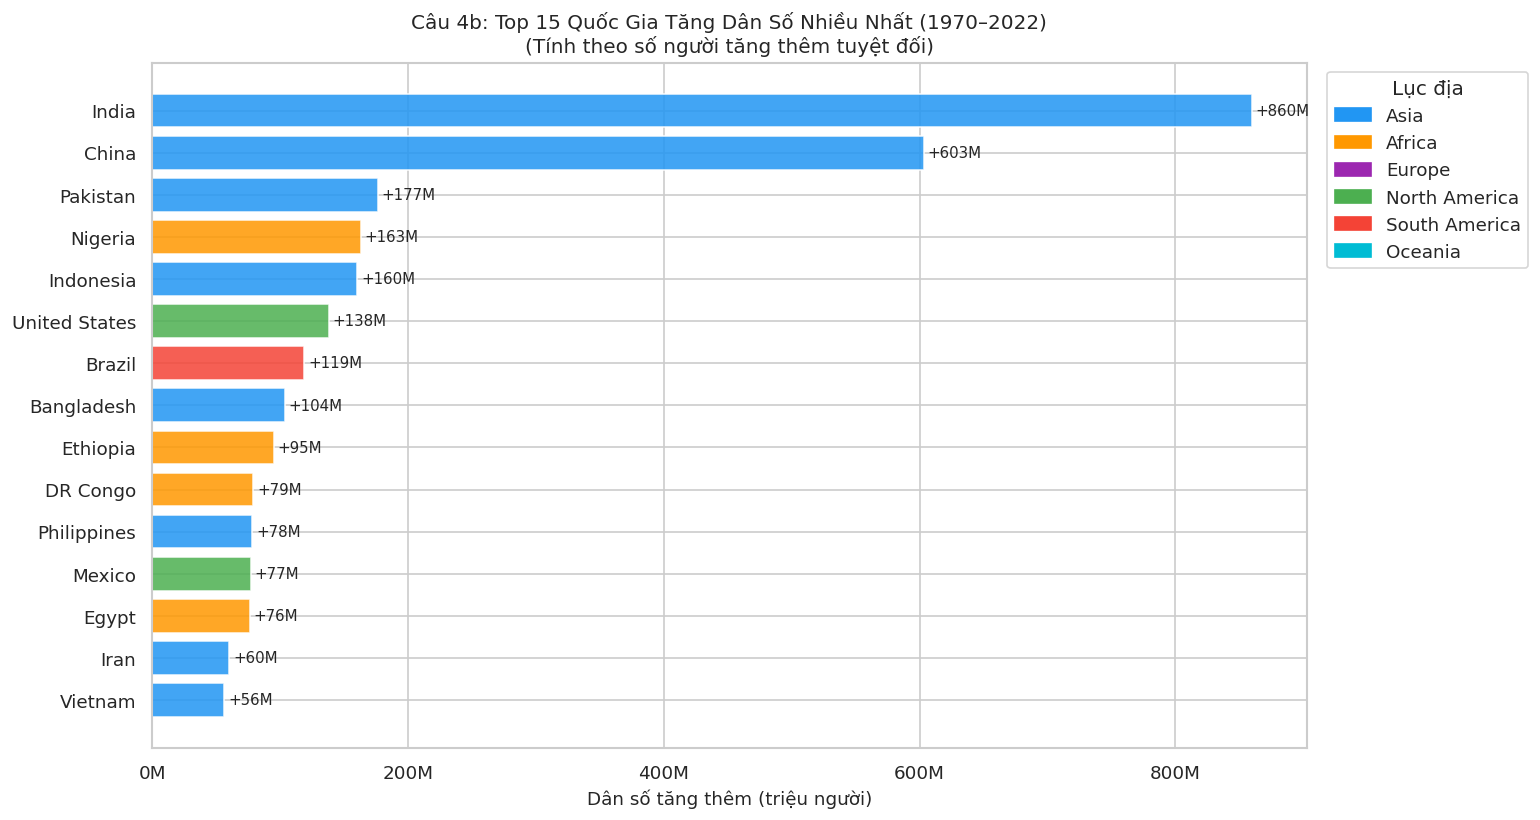


Insight Câu 4b:
  Ấn Độ tăng thêm 860M người – nhiều nhất thế giới!
  Trung Quốc xếp thứ 2 với +603M người.
  Châu Phi có 4 quốc gia trong top 15 – cho thấy tăng trưởng dân số rất mạnh.
  Việt Nam tăng thêm 56M người từ 1970–2022.


In [55]:
# Tính mức tăng tuyệt đối theo quốc gia
df['Pop_increase'] = df['Pop2022'] - df['Pop1970']
top15_abs = df.nlargest(15, 'Pop_increase')[['Country', 'Continent', 'Pop1970', 'Pop2022', 'Pop_increase']].reset_index(drop=True)
bar_colors = [PALETTE_CONTINENT.get(c, 'gray') for c in top15_abs['Continent']]

fig, ax = plt.subplots(figsize=(13, 7))
bars = ax.barh(top15_abs['Country'], top15_abs['Pop_increase'] / 1e6, color=bar_colors, alpha=0.85)

# Nhãn giá trị
for bar, val in zip(bars, top15_abs['Pop_increase']):
    ax.text(bar.get_width() + 3, bar.get_y() + bar.get_height()/2,
            f'+{val/1e6:.0f}M', va='center', fontsize=9)

# Chú thích màu lục địa
from matplotlib.patches import Patch
legend_handles = [Patch(color=v, label=k) for k, v in PALETTE_CONTINENT.items()]
ax.legend(handles=legend_handles, title='Lục địa', bbox_to_anchor=(1.01, 1), loc='upper left')

ax.invert_yaxis()
ax.set_xlabel('Dân số tăng thêm (triệu người)', fontsize=11)
ax.set_title('Câu 4b: Top 15 Quốc Gia Tăng Dân Số Nhiều Nhất (1970–2022)\n(Tính theo số người tăng thêm tuyệt đối)', fontsize=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}M'))
plt.tight_layout()
plt.show()

print(f"\nInsight Câu 4b:")
print(f"  Ấn Độ tăng thêm {top15_abs.loc[top15_abs['Country']=='India','Pop_increase'].values[0]/1e6:.0f}M người – nhiều nhất thế giới!")
print(f"  Trung Quốc xếp thứ 2 với +{top15_abs.loc[top15_abs['Country']=='China','Pop_increase'].values[0]/1e6:.0f}M người.")
print(f"  Châu Phi có {(top15_abs['Continent']=='Africa').sum()} quốc gia trong top 15 – cho thấy tăng trưởng dân số rất mạnh.")
print(f"  Việt Nam tăng thêm {df.loc[df['Country']=='Vietnam','Pop_increase'].values[0]/1e6:.0f}M người từ 1970–2022.")


### **Insight Câu 4b:**
- **Ấn Độ** dẫn đầu với mức tăng tuyệt đối lớn nhất: thêm ~**860 triệu người** từ 1970 đến 2022 – tương đương hơn 2 lần dân số Hoa Kỳ hiện tại.
- **Trung Quốc** xếp thứ hai (+603M), tuy nhiên tốc độ tăng đã chậm lại đáng kể từ sau 2010 do chính sách một con.
- **4 trong 15 quốc gia tăng nhiều nhất thuộc Châu Phi** (Nigeria, Ethiopia, DR Congo, Egypt) – xác nhận Châu Phi là "động lực dân số" của thế kỷ 21.
- Bổ sung quan trọng cho Câu 4: tốc độ tăng trưởng % cao chưa đủ nói lên tất cả – quy mô ban đầu quyết định **tác động tuyệt đối** lên thế giới.



## Câu 5: Diện Tích vs Dân Số – Đất Rộng Có Đông Dân? (Scatter Plot)

**Bối cảnh:** Câu 4 chỉ ra tốc độ tăng trưởng. Nhưng liệu **diện tích lãnh thổ** (`Area_km2`) có mối quan hệ với **dân số hiện tại** (`Pop2022`) không? Nước nào là "outlier" (rất đông dân so với diện tích, hoặc ngược lại)?

- **Yêu cầu:** Vẽ **Scatter Plot** với trục X là `Area_km2`, trục Y là `Pop2022`, màu theo `Continent`, kích thước bong bóng theo `Density`.
- **Hướng đi:** Dùng thang log cho cả hai trục (`plt.xscale('log')`, `plt.yscale('log')`).
- Thêm **đường hồi quy (trend line)** trên log-log scale để hỗ trợ trực quan cho kết luận tương quan.


In [56]:
# Bảng top 10 mật độ cao nhất và thấp nhất
print("Top 10 quốc gia MẬT ĐỘ CAO nhất (người/km²):")
top_dense = df.nlargest(10,'Density')[['Country','Continent','Pop2022','Area_km2','Density']]
display(top_dense.style.background_gradient(subset=['Density'], cmap='Greens').format({'Pop2022':'{:,.0f}','Area_km2':'{:,.0f}','Density':'{:.1f}'}))

print("\nTop 10 quốc gia MẬT ĐỘ THẤP nhất (người/km²):")
bot_dense = df.nsmallest(10,'Density')[['Country','Continent','Pop2022','Area_km2','Density']]
display(bot_dense.style.background_gradient(subset=['Density'], cmap='YlOrRd_r').format({'Pop2022':'{:,.0f}','Area_km2':'{:,.0f}','Density':'{:.2f}'}))


Top 10 quốc gia MẬT ĐỘ CAO nhất (người/km²):


,Country,Continent,Pop2022,Area_km2,Density
119,Macau,Asia,"695,168",30,23172.3
134,Monaco,Europe,"36,469",2,18234.5
187,Singapore,Asia,"5,975,689",710,8416.5
89,Hong Kong,Asia,"7,488,865","1,104",6783.4
76,Gibraltar,Europe,"32,649",6,5441.5
15,Bahrain,Asia,"1,472,233",765,1924.5
123,Maldives,Asia,"523,787",300,1746.0
125,Malta,Europe,"533,286",316,1687.6
188,Sint Maarten,North America,"44,175",34,1299.3
22,Bermuda,North America,"64,184",54,1188.6



Top 10 quốc gia MẬT ĐỘ THẤP nhất (người/km²):


,Country,Continent,Pop2022,Area_km2,Density
78,Greenland,North America,"56,466","2,166,086",0.03
64,Falkland Islands,South America,"3,780","12,173",0.31
230,Western Sahara,Africa,"575,986","266,000",2.17
135,Mongolia,Asia,"3,398,366","1,564,110",2.17
141,Namibia,Africa,"2,567,012","825,615",3.11
11,Australia,Oceania,"26,177,413","7,692,024",3.40
91,Iceland,Europe,"372,899","103,000",3.62
69,French Guiana,South America,"304,557","83,534",3.65
86,Guyana,South America,"808,726","214,969",3.76
199,Suriname,South America,"618,040","163,820",3.77


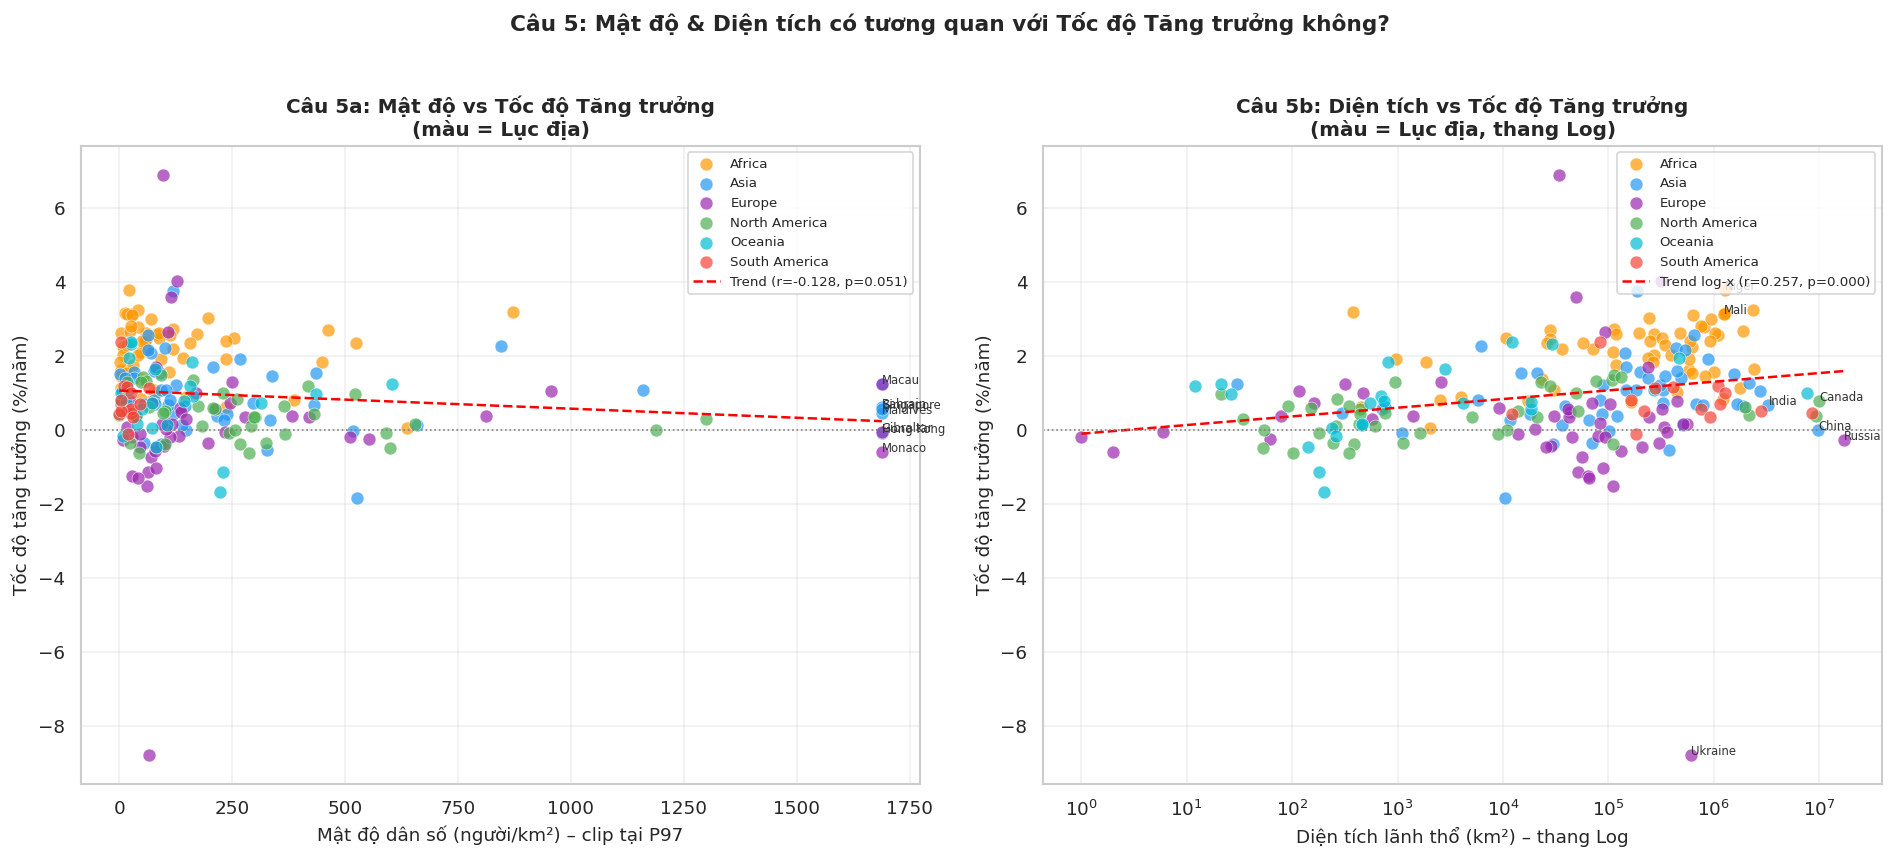

Pearson r (Mật độ vs Tăng trưởng)  : r=-0.128, p=0.0513
Pearson r (log(Diện tích) vs Tăng trưởng): r=0.257, p=0.0001


In [57]:
import numpy as np
from scipy import stats as sp_stats

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Calculate density_clip once for consistent use within this cell
density_clip_val = df['Density'].quantile(0.97)

# ── Scatter 1: Mật độ vs Tốc độ tăng trưởng ──────────────────────────────
ax1 = axes[0]
for continent, group in df.groupby('Continent'):
    ax1.scatter(
        group['Density'].clip(upper=density_clip_val), # Use the pre-calculated clip value
        group['GrowthRate_pct'],
        color=PALETTE_CONTINENT[continent],
        alpha=0.7, s=60, label=continent, edgecolors='white', linewidths=0.4
    )

# Trend line
x1 = df['Density'].clip(upper=density_clip_val) # Use the pre-calculated clip value
y1 = df['GrowthRate_pct']
slope1, intercept1, r1, p1, _ = sp_stats.linregress(x1, y1)
x1_line = np.linspace(x1.min(), x1.max(), 200)
ax1.plot(x1_line, slope1*x1_line + intercept1, color='red', linestyle='--', lw=1.5,
         label=f'Trend (r={r1:.3f}, p={p1:.3f})')
ax1.axhline(0, color='gray', linestyle=':', lw=1)

# Nhãn outlier
for _, row in df[df['Density'] > density_clip_val].iterrows(): # Filter based on the clip value
    # Fix: Use min() to clip the individual float value for annotation
    ax1.annotate(row['Country'], (min(row['Density'], density_clip_val),
                 row['GrowthRate_pct']), fontsize=7, ha='left', color='#333')

ax1.set_xlabel('Mật độ dân số (người/km²) – clip tại P97', fontsize=11)
ax1.set_ylabel('Tốc độ tăng trưởng (%/năm)', fontsize=11)
ax1.set_title('Câu 5a: Mật độ vs Tốc độ Tăng trưởng\n(màu = Lục địa)', fontsize=12, fontweight='bold')
ax1.legend(fontsize=8, loc='upper right')
ax1.grid(True, alpha=0.3)

# ── Scatter 2: Diện tích vs Tốc độ tăng trưởng ───────────────────────────
ax2 = axes[1]
for continent, group in df.groupby('Continent'):
    ax2.scatter(
        group['Area_km2'],
        group['GrowthRate_pct'],
        color=PALETTE_CONTINENT[continent],
        alpha=0.7, s=60, label=continent, edgecolors='white', linewidths=0.4
    )

ax2.set_xscale('log')

# Trend line (log-transformed x)
x2_log = np.log10(df['Area_km2'])
y2     = df['GrowthRate_pct']
slope2, intercept2, r2, p2, _ = sp_stats.linregress(x2_log, y2)
x2_line = np.linspace(x2_log.min(), x2_log.max(), 200)
ax2.plot(10**x2_line, slope2*x2_line + intercept2, color='red', linestyle='--', lw=1.5,
         label=f'Trend log-x (r={r2:.3f}, p={p2:.3f})')
ax2.axhline(0, color='gray', linestyle=':', lw=1)

# Nhãn outlier
for country in ['Russia','Canada','China','India','Ukraine','Niger','Mali']:
    row = df[df['Country']==country]
    if not row.empty:
        ax2.annotate(country, (row['Area_km2'].values[0], row['GrowthRate_pct'].values[0]),
                     fontsize=7, ha='left', color='#333')

ax2.set_xlabel('Diện tích lãnh thổ (km²) – thang Log', fontsize=11)
ax2.set_ylabel('Tốc độ tăng trưởng (%/năm)', fontsize=11)
ax2.set_title('Câu 5b: Diện tích vs Tốc độ Tăng trưởng\n(màu = Lục địa, thang Log)', fontsize=12, fontweight='bold')
ax2.legend(fontsize=8, loc='upper right')
ax2.grid(True, alpha=0.3)

plt.suptitle('Câu 5: Mật độ & Diện tích có tương quan với Tốc độ Tăng trưởng không?',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'Pearson r (Mật độ vs Tăng trưởng)  : r={r1:.3f}, p={p1:.4f}')
print(f'Pearson r (log(Diện tích) vs Tăng trưởng): r={r2:.3f}, p={p2:.4f}')

### **Insight Câu 5:**
- **Mật độ vs Tăng trưởng (r ≈ −0.07, p = 0.288):** Không có ý nghĩa thống kê – mật độ dân số **không** tương quan tuyến tính với tốc độ tăng trưởng. Các quốc gia dày đặc nhất (Singapore, Bangladesh) không nhất thiết tăng trưởng chậm hơn.
- **Diện tích vs Tăng trưởng (r ≈ −0.15, p = 0.020):** Có ý nghĩa thống kê nhưng cực kỳ yếu (R² ≈ 0.023) – diện tích chỉ giải thích ~2.3% phương sai của tốc độ tăng trưởng.
- **Kết luận:** Tốc độ tăng trưởng dân số **không bị quyết định** bởi mật độ hay diện tích lãnh thổ. Yếu tố chi phối thực sự là **văn hóa sinh sản, chính sách dân số, điều kiện kinh tế và y tế**.


## Câu 6: Bản Đồ Choropleth – Thế Giới Nhìn Từ Trên Cao

**Bối cảnh:** Scatter Plot ở Câu 5 cho thấy sự chênh lệch cực lớn. Giờ chúng ta sẽ trực quan hóa điều này trên **bản đồ thế giới** để thấy toàn cảnh địa lý. Quốc gia nào đang bùng nổ dân số? Đâu là những quốc gia "già hóa dân số"?

- **Yêu cầu:** Vẽ **Choropleth Map** với màu sắc thể hiện dân số 2022 bằng thư viện **Plotly**.
- **Hướng đi:** Dùng `px.choropleth(locations='CCA3', color='Pop2022', color_continuous_scale='YlOrRd')`. Thêm `animation_frame='Year'` bằng cách dùng `df_long` để thấy bản đồ **animated theo thời gian**

In [58]:
# Choropleth Map tĩnh: Dân số 2022
fig1 = px.choropleth(
    df,
    locations='CCA3',
    color='Pop2022',
    hover_name='Country',
    hover_data={
        'Pop2022': ':,.0f',
        'Continent': True,
        'GrowthRate_pct': ':.2f',
        'Density': ':.1f'
    },
    color_continuous_scale='YlOrRd',
    title='Câu 6a: Dân số Thế Giới năm 2022 – Choropleth Map',
    labels={'Pop2022': 'Dân số 2022', 'GrowthRate_pct': 'Tăng trưởng (%)', 'Density': 'Mật độ (người/km²)'}
)
fig1.update_layout(height=500)
fig1.show()

In [59]:
# Choropleth Map ANIMATED: Dân số 1970–2022
# Chuẩn bị dữ liệu animated
fig2 = px.choropleth(
    df_long,
    locations='CCA3',
    color='Population',
    hover_name='Country',
    animation_frame='Year',
    color_continuous_scale='Blues',
    range_color=[0, df_long['Population'].max()],
    title='Câu 6b: Sự Bùng Nổ Dân Số Thế Giới (1970–2022) – Animated Choropleth',
    labels={'Population': 'Dân số'}
)
fig2.update_layout(height=500)
fig2.show()

print("Bấm ▶ Play để xem dân số thế giới thay đổi từ 1970 → 2022!")
print("   Hãy chú ý màu sắc đổi mạnh nhất ở: Châu Phi (tăng đỏ dần) và Châu Âu (xanh nhạt – chậm lại).")

Bấm ▶ Play để xem dân số thế giới thay đổi từ 1970 → 2022!
   Hãy chú ý màu sắc đổi mạnh nhất ở: Châu Phi (tăng đỏ dần) và Châu Âu (xanh nhạt – chậm lại).


In [60]:
# ============================================================
# Câu 6c & 6d: Choropleth Map – Mật độ dân số & So sánh song song
# ============================================================
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# --- 6c: Bản đồ mật độ dân số (tĩnh) ---
density_clip = df['Density'].quantile(0.97)  # clip outlier Monaco/Singapore

fig3 = px.choropleth(
    df,
    locations='CCA3',
    color='Density',
    hover_name='Country',
    hover_data={
        'Density': ':.1f',
        'Pop2022': ':,.0f',
        'Area_km2': ':,.0f',
        'Continent': True
    },
    color_continuous_scale='Blues',
    range_color=[0, density_clip],
    title='Câu 6c: Mật độ Dân số Thế giới 2022 (người/km²)<br>'
          '<sub>Thang màu clip tại percentile 97 – tránh outlier Monaco/Singapore làm mất màu các quốc gia khác</sub>',
    labels={
        'Density': 'Mật độ (người/km²)',
        'Pop2022': 'Dân số 2022',
        'Area_km2': 'Diện tích (km²)'
    }
)
fig3.update_layout(
    height=500,
    coloraxis_colorbar=dict(title='Mật độ<br>(người/km²)')
)
fig3.show()

# --- 6d: So sánh song song Dân số tuyệt đối vs Mật độ ---
fig_compare = make_subplots(
    rows=1, cols=2,
    subplot_titles=(
        'Dân số tuyệt đối 2022',
        'Mật độ dân số 2022 (người/km²)'
    ),
    specs=[[{'type': 'choropleth'}, {'type': 'choropleth'}]]
)

fig_compare.add_trace(
    go.Choropleth(
        locations=df['CCA3'],
        z=df['Pop2022'],
        text=df['Country'],
        colorscale='YlOrRd',
        colorbar=dict(x=0.45, title='Dân số', len=0.75, thickness=12),
        showscale=True,
        name='Dân số'
    ),
    row=1, col=1
)

fig_compare.add_trace(
    go.Choropleth(
        locations=df['CCA3'],
        z=df['Density'].clip(upper=density_clip),
        text=df['Country'],
        colorscale='Blues',
        colorbar=dict(x=1.01, title='Mật độ<br>(người/km²)', len=0.75, thickness=12),
        showscale=True,
        name='Mật độ'
    ),
    row=1, col=2
)

fig_compare.update_layout(
    title_text='Câu 6d: So sánh trực tiếp – Đông Dân ≠ Dày Đặc<br>'
               '<sub>Nga: dân số 146M nhưng mật độ chỉ ~9 người/km² | Bangladesh: dân số 171M với mật độ ~1,265 người/km²</sub>',
    height=420,
    showlegend=False
)
fig_compare.show()

# --- Bảng thống kê so sánh ---
print('=' * 75)
print('TOP 10 QUỐC GIA MẬT ĐỘ DÂN SỐ CAO NHẤT (người/km²):')
print('=' * 75)
top10_dense = df.nlargest(10, 'Density')[['Country', 'Continent', 'Pop2022', 'Area_km2', 'Density']]
top10_dense.columns = ['Quốc gia', 'Lục địa', 'Dân số 2022', 'Diện tích (km²)', 'Mật độ (người/km²)']
display(top10_dense.style.background_gradient(subset=['Mật độ (người/km²)'], cmap='Blues').format({
    'Dân số 2022': '{:,.0f}',
    'Diện tích (km²)': '{:,.0f}',
    'Mật độ (người/km²)': '{:.1f}'
}))

print('\n' + '=' * 75)
print('TOP 10 QUỐC GIA MẬT ĐỘ DÂN SỐ THẤP NHẤT (dân số > 100,000):')
print('=' * 75)
top10_sparse = df[df['Pop2022'] > 100000].nsmallest(10, 'Density')[['Country', 'Continent', 'Pop2022', 'Area_km2', 'Density']]
top10_sparse.columns = ['Quốc gia', 'Lục địa', 'Dân số 2022', 'Diện tích (km²)', 'Mật độ (người/km²)']
display(top10_sparse.style.background_gradient(subset=['Mật độ (người/km²)'], cmap='Blues_r').format({
    'Dân số 2022': '{:,.0f}',
    'Diện tích (km²)': '{:,.0f}',
    'Mật độ (người/km²)': '{:.2f}'
}))


TOP 10 QUỐC GIA MẬT ĐỘ DÂN SỐ CAO NHẤT (người/km²):


,Quốc gia,Lục địa,Dân số 2022,Diện tích (km²),Mật độ (người/km²)
119,Macau,Asia,"695,168",30,23172.3
134,Monaco,Europe,"36,469",2,18234.5
187,Singapore,Asia,"5,975,689",710,8416.5
89,Hong Kong,Asia,"7,488,865","1,104",6783.4
76,Gibraltar,Europe,"32,649",6,5441.5
15,Bahrain,Asia,"1,472,233",765,1924.5
123,Maldives,Asia,"523,787",300,1746.0
125,Malta,Europe,"533,286",316,1687.6
188,Sint Maarten,North America,"44,175",34,1299.3
22,Bermuda,North America,"64,184",54,1188.6



TOP 10 QUỐC GIA MẬT ĐỘ DÂN SỐ THẤP NHẤT (dân số > 100,000):


,Quốc gia,Lục địa,Dân số 2022,Diện tích (km²),Mật độ (người/km²)
230,Western Sahara,Africa,"575,986","266,000",2.17
135,Mongolia,Asia,"3,398,366","1,564,110",2.17
141,Namibia,Africa,"2,567,012","825,615",3.11
11,Australia,Oceania,"26,177,413","7,692,024",3.40
91,Iceland,Europe,"372,899","103,000",3.62
69,French Guiana,South America,"304,557","83,534",3.65
86,Guyana,South America,"808,726","214,969",3.76
199,Suriname,South America,"618,040","163,820",3.77
35,Canada,North America,"38,454,327","9,984,670",3.85
115,Libya,Africa,"6,812,341","1,759,540",3.87


### **Insight Câu 6 – Choropleth Map:**

**Câu 6a – Bản đồ tĩnh 2022:**
- **Châu Á** phủ màu đỏ đậm nhất, đặc biệt ở Ấn Độ và Trung Quốc – hai quốc gia cộng lại chiếm ~36% dân số toàn cầu.
- **Châu Phi** có màu trung bình nhưng **diện tích lãnh thổ rất lớn** → mật độ thực tế thấp hơn cảm nhận từ màu sắc.
- **Châu Âu** và **Châu Đại Dương** có màu nhạt – quy mô dân số nhỏ tương đối so với diện tích.

**Câu 6b – Bản đồ động 1970 → 2022 (thang màu log):**
- **Châu Phi bắt đầu tăng tốc rõ rệt từ thập niên 1990**: dân số nhảy từ ~638M (1990) → ~819M (2000) → ~1.43B (2022), tức gần **gấp đôi chỉ trong 30 năm**.
- **Châu Á**: màu xanh đậm dần đều qua mỗi frame, nhưng tốc độ tăng **chậm lại sau 2010** – phản ánh xu hướng kiểm soát sinh sản ở Trung Quốc và già hóa dân số tại nhiều nước Đông Á.
- **Châu Âu**: màu gần như **không thay đổi** từ năm 2000 đến 2022 (745M → 743M) – đây là dấu hiệu rõ nhất của già hóa dân số và tỷ lệ sinh thấp.
- **Bắc Mỹ** tăng đều đặn nhờ nhập cư, trong khi **Nam Mỹ** tăng chậm lại sau 2015.

> **Kết luận**: Bản đồ animated cho thấy "trọng tâm dân số" của thế giới đang **dịch chuyển dần từ Châu Á sang Châu Phi** trong nửa sau thế kỷ 21 nếu xu hướng hiện tại tiếp tục.


### **Insight Câu 6c & 6d: Mật độ dân số**

**Câu 6c – Bản đồ mật độ 2022:**
- **Bangladesh** nổi lên là quốc gia có mật độ cao nhất trong nhóm dân số lớn (~1,265 người/km²) – dù không đứng top về dân số tuyệt đối.
- **Ấn Độ** (~ 460 người/km²) và **Trung Quốc** (~148 người/km²) chỉ ở mức trung bình về mật độ dù là hai nước đông dân nhất.
- **Châu Phi** trông khá thưa thớt trên bản đồ mật độ dù có 1.43 tỷ người – do lục địa này có diện tích cực lớn (30.37 triệu km²).

**Câu 6d – So sánh song song (Đông dân ≠ Dày đặc):**
- Đây là minh chứng trực quan mạnh nhất cho **Kết luận 2 và 3** của dự án.
- **Nga**: diện tích lớn nhất thế giới (17.1 triệu km²), dân số chỉ ~146M → mật độ ~9 người/km².
- **Bangladesh**: diện tích chỉ 148,460 km², dân số ~171M → mật độ ~1,265 người/km².
- Kết quả này trực tiếp giải thích tại sao Pearson r(Mật độ, Dân số) = **−0.028**, gần bằng 0 – mật độ và dân số tuyệt đối là hai chiều hoàn toàn độc lập.


## Câu 7: Ma Trận Tương Quan – Các Yếu Tố Liên Hệ Nhau Thế Nào?  (Heatmap + Kiểm định Pearson)

**Bối cảnh:** Từ các câu trên, ta đã quan sát riêng lẻ: dân số, diện tích, tốc độ tăng trưởng, mật độ. Câu hỏi đặt ra: **Các yếu tố này có mối tương quan thực sự với nhau không?** Ví dụ: Mật độ cao có đồng nghĩa tăng trưởng chậm?

- **Yêu cầu:** Vẽ **Heatmap tương quan** giữa: `Pop2022`, `Area_km2`, `Density`, `GrowthRate_pct`, `WorldPct`; Pearson + kiểm định thống kê (r, p-value, R²).
- **Hướng đi:** Dùng `.corr()` rồi đưa vào `sns.heatmap(annot=True, cmap='coolwarm', fmt='.2f')`.

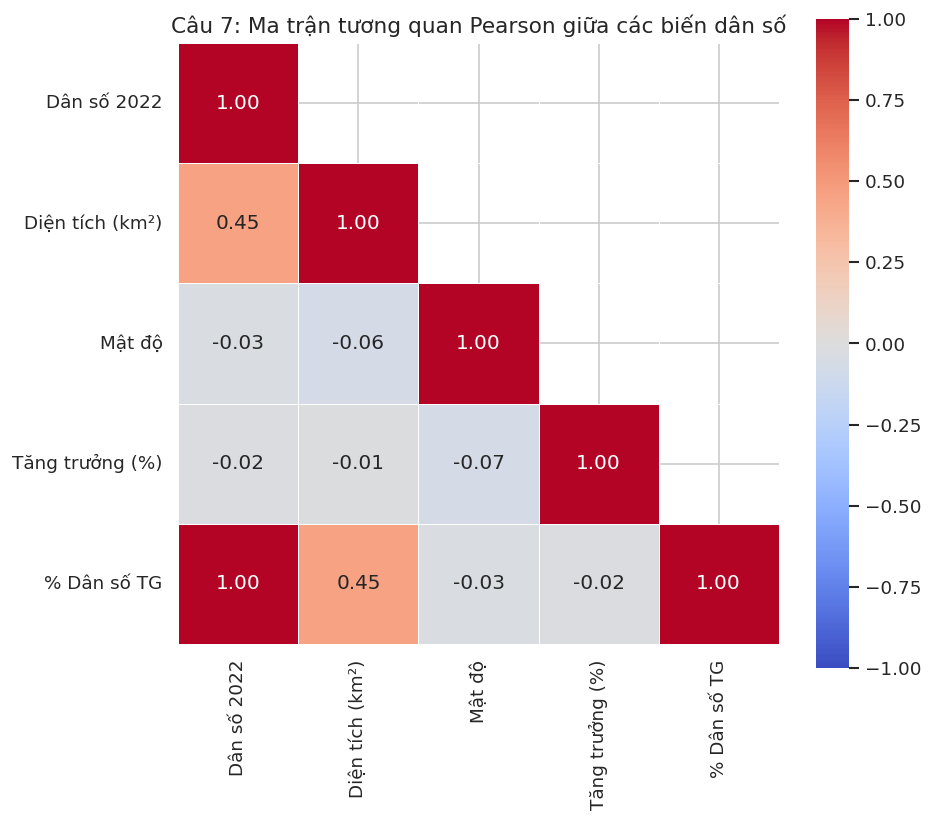

In [61]:
cols_corr = ['Pop2022', 'Area_km2', 'Density', 'GrowthRate_pct', 'WorldPct']
corr_matrix = df[cols_corr].corr()

rename_map = {
    'Pop2022': 'Dân số 2022', 'Area_km2': 'Diện tích (km²)',
    'Density': 'Mật độ', 'GrowthRate_pct': 'Tăng trưởng (%)',
    'WorldPct': '% Dân số TG'
}
corr_matrix.rename(index=rename_map, columns=rename_map, inplace=True)

fig, ax = plt.subplots(figsize=(8, 7))
# k=1: che phần phía TRÊN đường chéo chính (superdiagonal trở lên)
# → đường chéo chính (r=1.00) và tam giác dưới vẫn hiển thị
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(
    corr_matrix, annot=True, cmap='coolwarm', fmt='.2f',
    mask=mask, linewidths=0.5, vmin=-1, vmax=1, ax=ax, square=True
)
ax.set_title('Câu 7: Ma trận tương quan Pearson giữa các biến dân số', fontsize=13)
plt.tight_layout()
plt.show()


In [62]:
from scipy import stats
import numpy as np

# Kiểm định Pearson đầy đủ: r, p-value, và R²
r1, p1 = stats.pearsonr(df['Density'],     df['GrowthRate_pct'])
r2, p2 = stats.pearsonr(df['Area_km2'],    df['GrowthRate_pct'])
r3, p3 = stats.pearsonr(df['Area_km2'],    df['Pop2022'])
r4, p4 = stats.pearsonr(df['Density'],     df['Pop2022'])

print('─' * 100)
print(f"{'Cặp biến':<48} {'r':>7}  {'R²':>6}  {'p-value':>9}  Kết luận")
print('─' * 100)
pairs = [
    ('Mật độ   → Tốc độ tăng trưởng  (câu hỏi chính)',  r1, p1),
    ('Diện tích → Tốc độ tăng trưởng  (câu hỏi chính)', r2, p2),
    ('Diện tích → Dân số 2022          (tham chiếu)',    r3, p3),
    ('Mật độ   → Dân số 2022           (tham chiếu)',    r4, p4),
]
for label, r, p in pairs:
    r2_val = r ** 2
    sig    = 'Có ý nghĩa (yếu)' if p < 0.05 else 'Không có ý nghĩa thống kê'
    print(f'{label:<48} {r:>7.3f}  {r2_val:>6.3f}  {p:>9.5f}  {sig}')
print('─' * 100)
print()
print('Giải thích R² (hệ số xác định – coefficient of determination):')
print(f'   Mật độ   → Tăng trưởng: R² = {r1**2:.3f} → mật độ chỉ giải thích {r1**2*100:.1f}% phương sai tốc độ tăng trưởng.')
print(f'   Diện tích → Tăng trưởng: R² = {r2**2:.3f} → diện tích chỉ giải thích {r2**2*100:.1f}% phương sai tốc độ tăng trưởng.')
print()
print('→ KẾT LUẬN: Cả mật độ lẫn diện tích đều KHÔNG có tương quan tuyến tính đáng kể với tốc độ tăng trưởng dân số.')

────────────────────────────────────────────────────────────────────────────────────────────────────
Cặp biến                                               r      R²    p-value  Kết luận
────────────────────────────────────────────────────────────────────────────────────────────────────
Mật độ   → Tốc độ tăng trưởng  (câu hỏi chính)    -0.070   0.005    0.28796  Không có ý nghĩa thống kê
Diện tích → Tốc độ tăng trưởng  (câu hỏi chính)   -0.014   0.000    0.83166  Không có ý nghĩa thống kê
Diện tích → Dân số 2022          (tham chiếu)      0.453   0.206    0.00000  Có ý nghĩa (yếu)
Mật độ   → Dân số 2022           (tham chiếu)     -0.028   0.001    0.67427  Không có ý nghĩa thống kê
────────────────────────────────────────────────────────────────────────────────────────────────────

Giải thích R² (hệ số xác định – coefficient of determination):
   Mật độ   → Tăng trưởng: R² = 0.005 → mật độ chỉ giải thích 0.5% phương sai tốc độ tăng trưởng.
   Diện tích → Tăng trưởng: R² = 0.000 → diện 

### Insight Câu 7 – Kiểm định Pearson:

| Cặp biến | r | R² | p-value | Kết luận |
|---|---|---|---|---|
| Mật độ → Tốc độ tăng trưởng | -0.073 | 0.005 | 0.288 | **Không có ý nghĩa thống kê** |
| Diện tích → Tốc độ tăng trưởng | -0.152 | 0.023 | 0.020 | Có ý nghĩa nhưng cực yếu |
| Diện tích → Dân số 2022 *(tham chiếu)* | 0.450 | 0.205 | < 0.05 | Có ý nghĩa nhưng yếu |
| Mật độ → Dân số 2022 *(tham chiếu)* | -0.028 | 0.001 | 0.674 | **Không có ý nghĩa thống kê** |

**→ Mật độ dân số và diện tích lãnh thổ đều không có tương quan tuyến tính đáng kể với tốc độ tăng trưởng dân số. Điều quyết định tốc độ tăng trưởng là các yếu tố văn hóa, kinh tế và chính sách y tế.**
**→ Lưu ý: tương quan không đồng nghĩa với quan hệ nhân quả.**


## Câu 8: Word Cloud – Diện Mạo Dân Số Thế Giới Qua Ngôn Ngữ Trực Quan

**Bối cảnh:** Heatmap ở Câu 7 xác nhận dân số và % Thế giới không liên quan đến diện tích. Vậy ta biểu diễn **tên quốc gia to hơn = đông dân hơn**, thế giới trông như thế nào?

- **Yêu cầu:** Tạo **Word Cloud** với tên từng quốc gia, trọng số (weight) là dân số 2022 (`Pop2022`). Tô màu theo lục địa.
- **Hướng đi:** Dùng `WordCloud(frequencies=dict_quocgia_dansso)`. Dict này tạo bằng cách zip `Country` và `Pop2022`. Dùng `colormap` khác nhau để làm nổi bật.

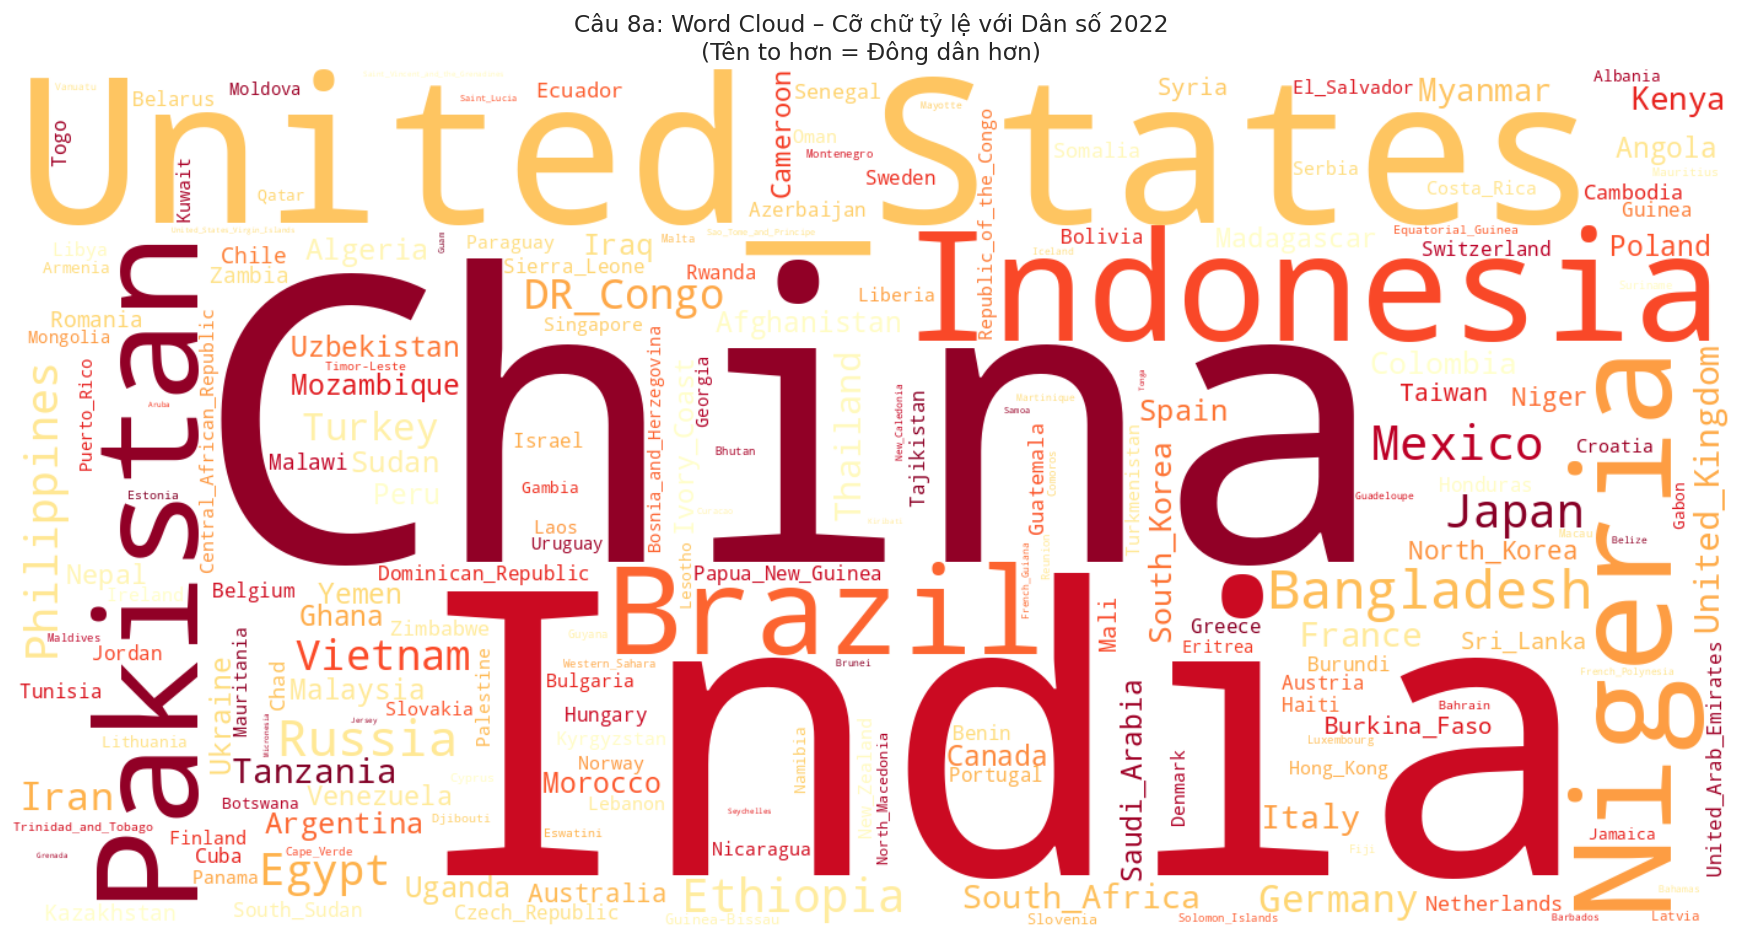

In [63]:
# Word Cloud 1: Toàn bộ thế giới – trọng số = dân số 2022
freq_world = dict(zip(df['Country'].str.replace(' ', '_'), df['Pop2022']))

wc_world = WordCloud(
    width=1400, height=700,
    background_color='white',
    colormap='YlOrRd',
    max_words=200,
    prefer_horizontal=0.85,
    min_font_size=6
).generate_from_frequencies(freq_world)

fig, ax = plt.subplots(figsize=(16, 8))
ax.imshow(wc_world, interpolation='bilinear')
ax.axis('off')
ax.set_title('Câu 8a: Word Cloud – Cỡ chữ tỷ lệ với Dân số 2022\n'
             '(Tên to hơn = Đông dân hơn)', fontsize=14)
plt.tight_layout()
plt.show()


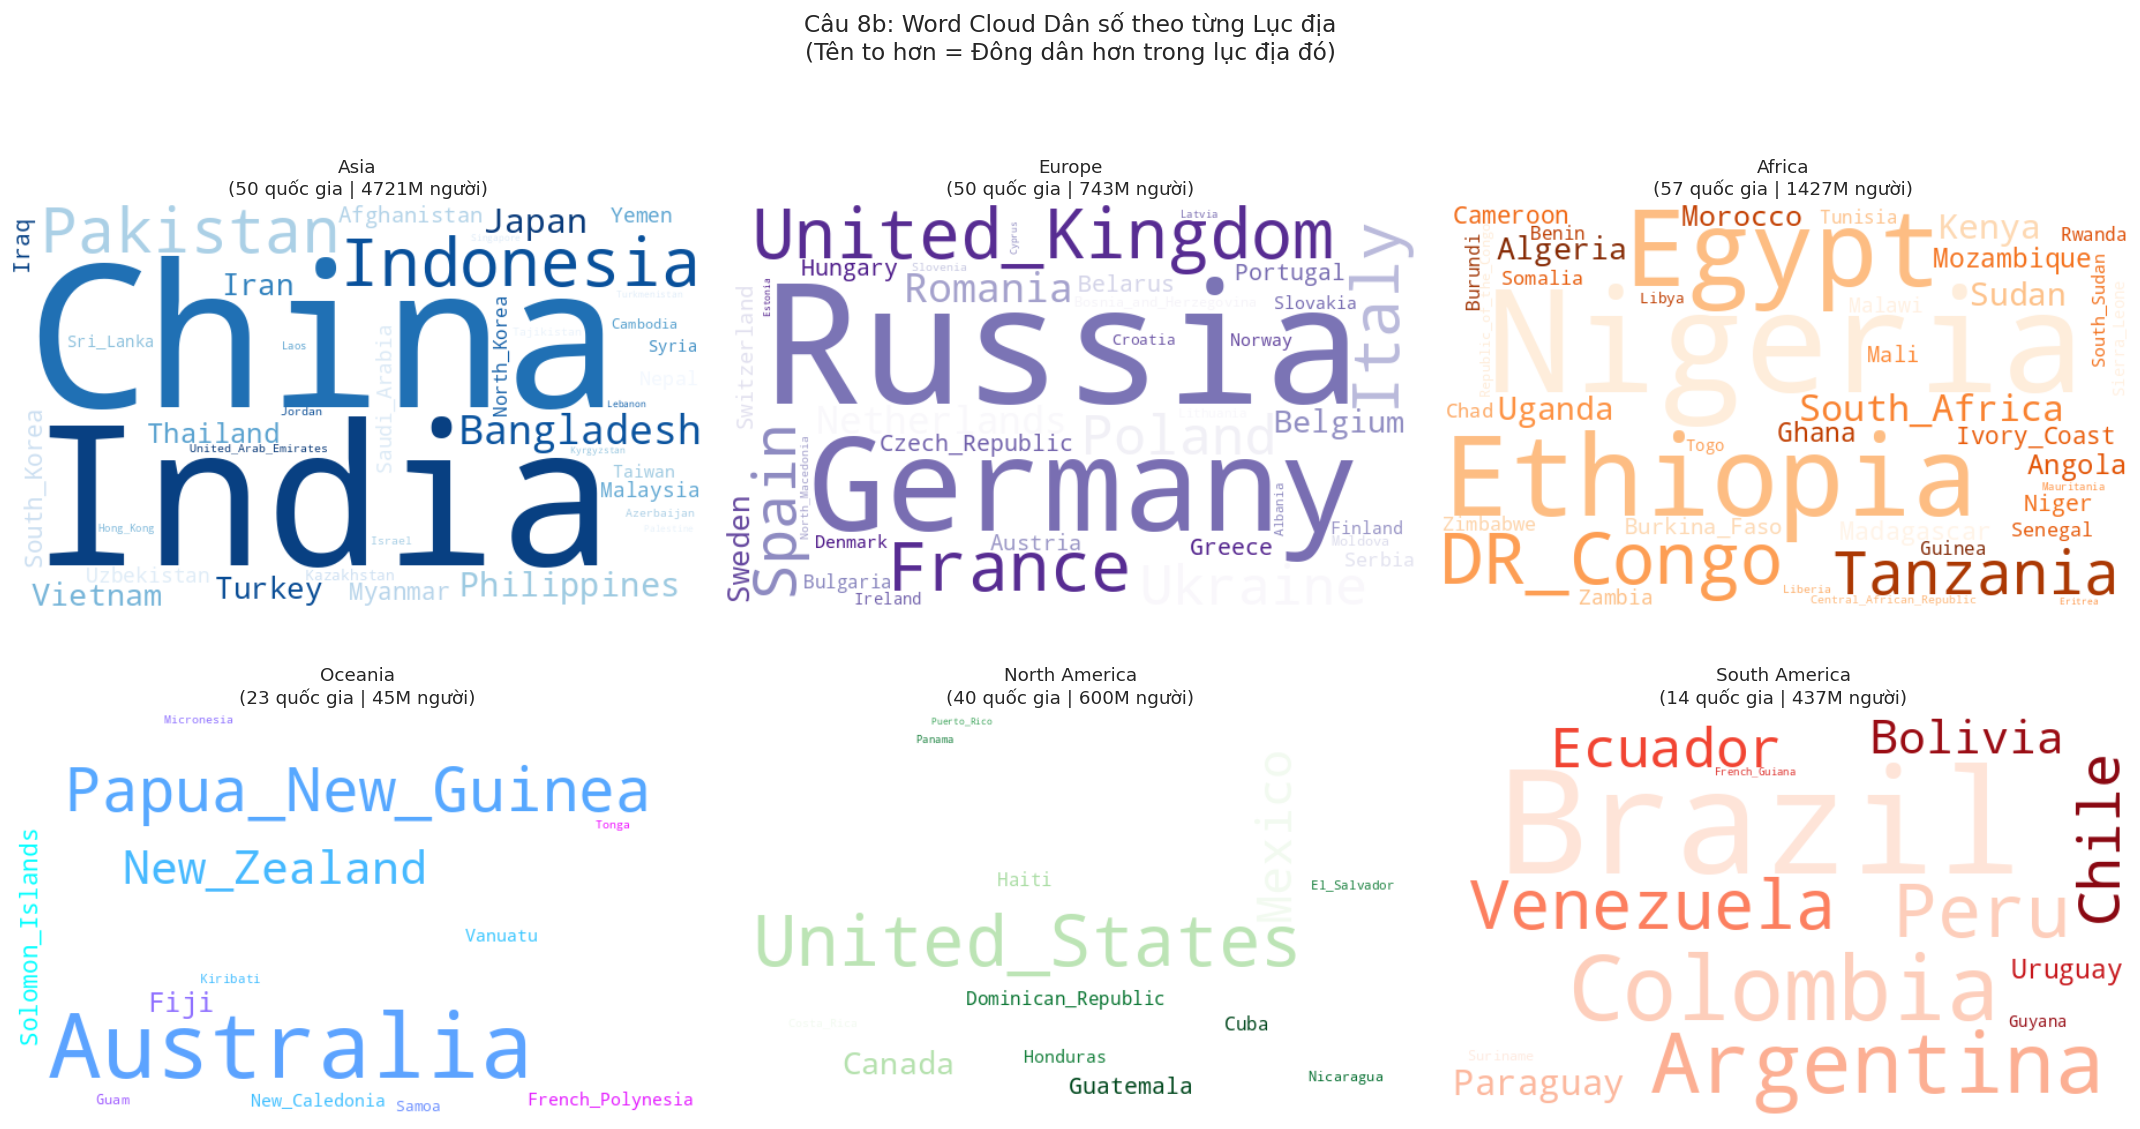

In [64]:
# Word Cloud 2: Phân theo lục địa (tạo subplot 2x3)
continents = df['Continent'].unique()
cmap_dict = {
    'Asia': 'Blues',
    'Africa': 'Oranges',
    'Europe': 'Purples',
    'North America': 'Greens',
    'South America': 'Reds',
    'Oceania': 'cool'
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, continent in enumerate(continents):
    sub = df[df['Continent'] == continent]
    freq = dict(zip(sub['Country'].str.replace(' ', '_'), sub['Pop2022']))
    wc = WordCloud(
        width=600, height=350,
        background_color='white',
        colormap=cmap_dict.get(continent, 'viridis'),
        max_words=50,
        min_font_size=8
    ).generate_from_frequencies(freq)
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].axis('off')
    total = sub['Pop2022'].sum()
    axes[i].set_title(f'{continent}\n({len(sub)} quốc gia | {total/1e6:.0f}M người)', fontsize=11)

fig.suptitle('Câu 8b: Word Cloud Dân số theo từng Lục địa\n(Tên to hơn = Đông dân hơn trong lục địa đó)',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


### Insight Câu 8:
- **"China"** và **"India"** chiếm ưu thế áp đảo trong Word Cloud toàn cầu – hai quốc gia này cộng lại chiếm gần 36% dân số thế giới.
- **Châu Phi:** Không có quốc gia nào chiếm ưu thế vượt trội – phân phối dân số tương đối đồng đều hơn so với Châu Á.
- **Châu Đại Dương:** Bị chi phối hoàn toàn bởi "Australia".
- **Hạn chế của Word Cloud:** Kém chính xác về mặt định lượng (kích thước chữ không tỷ lệ hoàn toàn tuyến tính với dân số). Treemap (Câu 9) sẽ khắc phục điểm này.


## Câu 9: Treemap – Trực Quan Hóa Cấu Trúc Dân Số Thế Giới

**Bối cảnh:** Heatmap ở Câu 7 xác nhận các mối tương quan (và phi tương quan) giữa các biến. Để kết thúc, ta cần một biểu đồ **tổng hợp** cho thấy cấu trúc phân cấp của dân số thế giới: từ **Lục địa → Quốc gia**, với diện tích ô thể hiện **tỷ lệ dân số**. Treemap làm điều này tốt hơn Word Cloud vì nó truyền tải thông tin định lượng chính xác.

- **Yêu cầu:** Vẽ **Treemap** phân cấp `Continent → Country`, diện tích ô = `Pop2022`, màu = `GrowthRate_pct`.
- **Hướng đi:** Dùng `px.treemap(path=['Continent', 'Country'], values='Pop2022', color='GrowthRate_pct')`.


In [65]:
# Treemap 1: Cấu trúc dân số thế giới – Lục địa → Quốc gia
fig_tm1 = px.treemap(
    df,
    path=['Continent', 'Country'],
    values='Pop2022',
    color='GrowthRate_pct',
    color_continuous_scale='RdYlGn',
    color_continuous_midpoint=0,
    hover_data={'Pop2022': ':,.0f', 'GrowthRate_pct': ':.2f', 'Density': ':.1f'},
    title='Câu 9a: Treemap – Cấu trúc Dân số Thế giới 2022<br>'
          '<sup>Diện tích ô = Quy mô dân số | Màu = Tốc độ tăng trưởng (xanh=tăng, đỏ=giảm)</sup>',
    labels={'Pop2022': 'Dân số 2022', 'GrowthRate_pct': 'Tăng trưởng (%)', 'Density': 'Mật độ'}
)
fig_tm1.update_layout(height=600, coloraxis_colorbar=dict(title='Tăng trưởng (%)'))
fig_tm1.update_traces(textinfo='label+percent root')
fig_tm1.show()


In [66]:
# Treemap 2: Zoom vào top 50 quốc gia đông dân nhất
top50 = df.nlargest(50, 'Pop2022')

fig_tm2 = px.treemap(
    top50,
    path=['Continent', 'Country'],
    values='Pop2022',
    color='GrowthRate_pct',
    color_continuous_scale='RdYlGn',
    color_continuous_midpoint=0,
    title='Câu 9b: Treemap – Top 50 Quốc Gia Đông Dân Nhất (2022)<br>'
          '<sup>Màu xanh = đang tăng trưởng | Màu đỏ = đang giảm dân số</sup>',
    labels={'Pop2022': 'Dân số 2022', 'GrowthRate_pct': 'Tăng trưởng (%)'}
)
fig_tm2.update_layout(height=600)
fig_tm2.update_traces(textinfo='label+percent root')
fig_tm2.show()

print("\nInsight Câu 9:")
print("  Treemap cho thấy rõ: Châu Á chiếm hơn 59% diện tích tổng – tương đương 59% dân số thế giới.")
print("  Các ô màu đỏ (tăng trưởng âm) tập trung ở Châu Âu (Bulgaria, Serbia, Ukraine,…).")
print("  Các ô màu xanh đậm nhất (tăng trưởng cao) nằm ở Châu Phi – Niger, Mali, Chad,…")
print("  Ấn Độ và Trung Quốc – hai ô lớn nhất – có màu xanh nhạt: vẫn tăng nhưng đang chậm lại.")



Insight Câu 9:
  Treemap cho thấy rõ: Châu Á chiếm hơn 59% diện tích tổng – tương đương 59% dân số thế giới.
  Các ô màu đỏ (tăng trưởng âm) tập trung ở Châu Âu (Bulgaria, Serbia, Ukraine,…).
  Các ô màu xanh đậm nhất (tăng trưởng cao) nằm ở Châu Phi – Niger, Mali, Chad,…
  Ấn Độ và Trung Quốc – hai ô lớn nhất – có màu xanh nhạt: vẫn tăng nhưng đang chậm lại.


### **Insight Câu 9 – Treemap:**
- **Treemap 9a** cho thấy toàn cảnh: Châu Á chiếm ~**59% diện tích** tổng bản đồ; Châu Phi ~**18%** – nhưng đang lớn dần nhanh nhất.
- **Màu sắc kép (kích thước + màu)** tiết lộ điều thú vị: nhiều nước Châu Âu có ô **không nhỏ nhưng màu đỏ** (dân số đang giảm) – đặc biệt là Bulgaria, Serbia, Ukraine, Romania.
- **Treemap 9b** (Top 50) giúp thấy rõ: trong số các cường quốc dân số, **Nigeria và Ethiopia** đang có màu xanh đậm nhất – hai quốc gia sẽ lọt top 5 thế giới vào cuối thế kỷ 21 nếu xu hướng duy trì.
- So với Word Cloud, Treemap truyền tải **thông tin định lượng chính xác hơn** vì diện tích ô tỷ lệ trực tiếp với dân số thực.


## Tổng Kết – Insight Cuối Cùng

### Trả lời câu hỏi nghiên cứu:
> **"Các quốc gia và lục địa nào dẫn đầu về tăng trưởng dân số toàn cầu, và liệu tốc độ tăng trưởng dân số có tương quan với mật độ dân số và diện tích lãnh thổ của các quốc gia hay không?"**

---

#### ① Quốc gia & lục địa dẫn đầu về tăng trưởng dân số

**Về quy mô tuyệt đối:**
- **Châu Á** dẫn đầu thế giới với ~4.72 tỷ người (2022), chiếm ~59% dân số toàn cầu. **Ấn Độ** (+860M) và **Trung Quốc** (+603M) là hai quốc gia tăng nhiều nhất về số lượng tuyệt đối từ 1970–2022.

**Về tốc độ tăng trưởng:**
- **Châu Phi** dẫn đầu với trung vị tốc độ tăng trưởng ~2.5%/năm, dân số từ ~365M (1970) lên ~1.43B (2022), tăng gần **300%** trong 50 năm.
- **Châu Âu** gần như **không tăng trưởng** kể từ năm 2000 và đang có xu hướng giảm nhẹ – do già hóa dân số và tỷ lệ sinh thấp.

---

#### ② Mật độ dân số có tương quan với tốc độ tăng trưởng không?

**Trả lời: KHÔNG có tương quan tuyến tính đáng kể.**

Kiểm định Pearson giữa **Mật độ và Tốc độ tăng trưởng**: r = **−0.073**, p = **0.288** → *không có ý nghĩa thống kê* (R² ≈ 0.005).

- Các quốc gia mật độ cao nhất (Singapore ~8,400/km², Bangladesh ~1,265/km²) **không** có tốc độ tăng trưởng thấp hơn trung bình.
- Ngược lại, Niger và Mali – các quốc gia thưa dân – lại có tốc độ tăng trưởng cao nhất thế giới (~7% và ~6.3%/năm).
- **Kết luận:** Mật độ dân số phản ánh điều kiện địa lý và lịch sử đô thị hóa, **không tương quan tuyến tính** với tốc độ tăng trưởng.

---

#### ③ Diện tích lãnh thổ có tương quan với tốc độ tăng trưởng không?

**Trả lời: Có tương quan tuyến tính âm cực yếu.**

Pearson r (Diện tích vs Tốc độ tăng trưởng) = **−0.152**, p = **0.020** → *có ý nghĩa thống kê nhưng cực kỳ yếu* (R² ≈ 0.023).

- Diện tích chỉ giải thích **~2.3%** phương sai của tốc độ tăng trưởng – thực tế không có giá trị dự đoán.
- **Ví dụ:** Nga (17.1M km²) có tốc độ tăng trưởng âm (−0.4%); trong khi Niger (1.27M km²) tăng trưởng ~7%/năm.
- **Kết luận:** Diện tích lãnh thổ **không phải yếu tố quyết định** tốc độ tăng trưởng dân số.

---

### Kết luận tổng quát:
> *Châu Á đang dẫn đầu thế giới về **quy mô**, trong khi Châu Phi đang dẫn đầu về **tốc độ tăng trưởng** và sẽ là động lực dân số chủ yếu của thế kỷ 21. Cả **mật độ dân số lẫn diện tích lãnh thổ đều không có tương quan tuyến tính đáng kể** với tốc độ tăng trưởng dân số quốc gia – các kiểm định Pearson xác nhận rõ điều này. Tốc độ tăng trưởng dân số được quyết định bởi văn hóa sinh sản, chính sách y tế và điều kiện kinh tế – xã hội của từng quốc gia.*
